# George Boufis f3352504


# Crime Analysis in Europe (1993–2007)

## Assignment 1
### Data Visualization

**Objective**

The objective of this project is to investigate whether the crime trends in Greece differ from those observed in the rest of Europe during the period 1993–2007.

The analysis includes:

- Data loading
- Data cleaning
- Exploratory Data Analysis (EDA)
- Static visualizations


In [ ]:
#pip install plotnine geopandas seaborn scikit-learn openpyxl

  Using cached plotnine-0.15.7-py3-none-any.whl.metadata (9.6 kB)
  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached mizani-0.14.4-py3-none-any.whl.metadata (4.8 kB)
  Using cached statsmodels-0.14.6-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached pyogrio-0.12.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (5.9 kB)
  Using cached pyproj-3.7.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached plotnine-0.15.7-py3-none-any.whl (1.6 MB)
Using cached mizani-0.14.4-py3-none-any.whl (133 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached pyogrio-0.12.1-cp312-cp312-macosx_12_0_arm64.whl (23.7 MB)
Using cached pyproj-3.7.2-cp312-cp312-macosx_14_0_arm64.whl (4.6 MB)
Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl (1.6 MB)
Using cached statsmodels-0.14.6-cp31

In [34]:
# Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon, Circle

import math 

import seaborn as sns

from pathlib import Path

from plotnine import *

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import geopandas as gpd

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
plt.style.use("default")

# Common colors
GREECE_COLOR = "#1f77b4"
EUROPE_COLOR = "#7f7f7f"
REFERENCE_COLOR = "#d62728"
OTHER_COLOR = "#BDBDBD"

### Project Configuration
This section defines the project structure by setting the paths for the data, figures, Tableau outputs, and presentation files. It also creates the required directories, if they do not already exist, and verifies that the input datasets are available before the analysis begins.

In [37]:
# Project paths

PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"

crime_path = DATA_DIR / "crim_gen_spreadsheet.xlsx"
population_path = DATA_DIR / "P_Data_Extract_From_World_Development_Indicators.xlsx"

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)

print("Crime file exists:", crime_path.exists())
print("Population file exists:", population_path.exists())

Project directory: /Users/giorgosboufis/Desktop/Data Visualization/Assignment 1/crime-analysis-europe
Data directory: /Users/giorgosboufis/Desktop/Data Visualization/Assignment 1/crime-analysis-europe/data
Crime file exists: True
Population file exists: True


### Inspecting the Input Datasets

This step loads the Excel workbooks and inspects their sheet names to understand the structure of the available data. It serves as an initial verification that the required datasets have been loaded correctly before the preprocessing stage.

In [38]:
crime_excel = pd.ExcelFile(crime_path)
population_excel = pd.ExcelFile(population_path)

print("Crime sheets:")
print(crime_excel.sheet_names)

print("\nPopulation sheets:")
print(population_excel.sheet_names)

Crime sheets:
['Summary', 'Structure', 'Sheet 1', 'Sheet 2', 'Sheet 3', 'Sheet 4', 'Sheet 5', 'Sheet 6', 'Sheet 7']

Population sheets:
['Data', 'Series - Metadata']


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default


### Loading the Datasets

This step loads the crime and population datasets into the Python Environment. It also provides a quick overview of their structure by displaying the available crime data sheets and the dimensions of the population dataset, ensuring that the data has been imported successfully before further processing.

In [39]:
# Crime dataset
crime_excel = pd.ExcelFile(crime_path)

# Population dataset
population_df = pd.read_excel(
    population_path,
    sheet_name="Data"
)

print("Crime sheets:")
print(crime_excel.sheet_names)

print("\nPopulation dataset shape:")
print(population_df.shape)

population_df.head()

Crime sheets:
['Summary', 'Structure', 'Sheet 1', 'Sheet 2', 'Sheet 3', 'Sheet 4', 'Sheet 5', 'Sheet 6', 'Sheet 7']

Population dataset shape:
(41, 19)


,Country Name,Country Code,Series Name,Series Code,1993 [YR1993],1994 [YR1994],1995 [YR1995],1996 [YR1996],1997 [YR1997],1998 [YR1998],1999 [YR1999],2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007]
0,Belgium,BEL,"Population, total",SP.POP.TOTL,10084475.0,10115603.0,10136811.0,10156637.0,10181245.0,10203008.0,10226419.0,10251250.0,10286570.0,10332785.0,10376133.0,10421137.0,10478617.0,10547958.0,10625700.0
1,Bulgaria,BGR,"Population, total",SP.POP.TOTL,8472313.0,8443591.0,8406067.0,8362826.0,8312068.0,8256786.0,8210624.0,8170172.0,8009142.0,7837161.0,7775327.0,7716860.0,7658972.0,7601022.0,7545338.0
2,Czechia,CZE,"Population, total",SP.POP.TOTL,10329855.0,10333587.0,10327253.0,10315241.0,10304131.0,10294373.0,10283860.0,10255063.0,10216605.0,10196916.0,10193998.0,10197101.0,10211216.0,10238905.0,10298828.0
3,Denmark,DNK,"Population, total",SP.POP.TOTL,5188628.0,5206180.0,5233373.0,5263074.0,5284991.0,5304219.0,5321799.0,5339616.0,5358783.0,5375931.0,5390574.0,5404523.0,5419432.0,5437272.0,5461438.0
4,Germany,DEU,"Population, total",SP.POP.TOTL,81156363.0,81438348.0,81678051.0,81914831.0,82034771.0,82047195.0,82100243.0,82211508.0,82349925.0,82488495.0,82534176.0,82516260.0,82469422.0,82376451.0,82266372.0


### Loading the Crime Data

This step loads all sheet from the crime dataset into a dictionary, where each sheet corresponds to a different crime category. The dimensions of each dataset are displayed to verify that all data have been imported correctly before the cleaning and transformation process.

In [40]:

crime_data = {}

for sheet in crime_excel.sheet_names:

    crime_data[sheet] = pd.read_excel(
        crime_path,
        sheet_name=sheet
    )

print("Loaded sheets:\n")

for name, df in crime_data.items():
    print(f"{name}: {df.shape}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/

Loaded sheets:

Summary: (21, 5)
Structure: (65, 3)
Sheet 1: (51, 16)
Sheet 2: (51, 16)
Sheet 3: (51, 16)
Sheet 4: (51, 16)
Sheet 5: (51, 16)
Sheet 6: (51, 16)
Sheet 7: (51, 16)


### Exploring the Crime Data

This step inspects the contents of each crime dataset by displaying a sample of the data and the corresponding column names. The objective is to understand the structure of raw data and identify any cleaning or transformation steps required before analysis.

In [41]:
for name, df in crime_data.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(df.head())

    print("\nColumns:")
    print(df.columns.tolist())

    print("\n")

Summary
                                          Unnamed: 0 Unnamed: 1 Unnamed: 2  \
0                                                NaN        NaN        NaN   
1                                                NaN        NaN        NaN   
2                                                NaN        NaN        NaN   
3                                                NaN        NaN        NaN   
4  Crimes recorded by the police by by offence ca...        NaN        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Columns:
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


Structure
   Structure                                         Unnamed: 1 Unnamed: 2
0        NaN                                          Dimension   Position
1        NaN                                              Label      Label
2        NaN                                     

### Mapping Crime Categories

This step assigns a meaningful crime category to each worksheet by creating a mapping between the sheet names and their corresponding offence types. This mapping simplifies the subsequent data processing and ensures that each observation is associated with the correct crime category.

In [42]:
crime_mapping = {
    "Sheet 1": "Total",
    "Sheet 2": "Intentional homicide",
    "Sheet 3": "Acts causing harm",
    "Sheet 4": "Robbery",
    "Sheet 5": "Burglary",
    "Sheet 6": "Motor vehicle theft",
    "Sheet 7": "Drug offences"
}

crime_mapping

{'Sheet 1': 'Total',
 'Sheet 2': 'Intentional homicide',
 'Sheet 3': 'Acts causing harm',
 'Sheet 4': 'Robbery',
 'Sheet 5': 'Burglary',
 'Sheet 6': 'Motor vehicle theft',
 'Sheet 7': 'Drug offences'}

### Cleaning and Reshaping the Crime Data

This step cleans the raw crime data by removing metadata rows and keeping only valid country observations. Each crime category is then transformed from wide format into long format, producting one row per country, crime type, and year. Crime counts are also converted to numeric values so they can be used in later calculations.

In [43]:
crime_tables = []

for sheet, crime_type in crime_mapping.items():

    temp = pd.read_excel(
        crime_path,
        sheet_name=sheet,
        header=8
    )

    # Rename first column
    temp = temp.rename(columns={"TIME": "Country"})

    # Keep only valid country rows
    temp = temp[
        temp["Country"].notna()
    ].copy()

    temp = temp[
        ~temp["Country"].isin([
            "GEO (Labels)",
            "Special value",
            ":"
        ])
    ].copy()

    # Add crime type
    temp["Crime_Type"] = crime_type

    # Convert from wide to long format
    temp_long = temp.melt(
        id_vars=["Country", "Crime_Type"],
        var_name="Year",
        value_name="Crime_Count"
    )

    temp_long["Year"] = temp_long["Year"].astype(int)

    temp_long["Crime_Count"] = pd.to_numeric(
        temp_long["Crime_Count"],
        errors="coerce"
    )

    crime_tables.append(temp_long)

crime_clean = pd.concat(
    crime_tables,
    ignore_index=True
)

crime_clean.sample(5)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
/Library/Frameworks/Python.framework/Versions/3.12/lib/

,Country,Crime_Type,Year,Crime_Count
1298,Croatia,Acts causing harm,1996,NaN
2711,Austria,Burglary,2002,12674.0
3543,Scotland,Drug offences,1993,5233.0
3357,Denmark,Motor vehicle theft,2004,31525.0
2865,Malta,Burglary,2006,856.0


### Validating the Cleaned Crime Dataset

This step verifies the quality of the cleaned crime dataset by examining its dimensions, the number of countries, crime categories, and years included. It also checks for missing values to ensure that the dataset is consistent and ready for further analysis.

In [44]:
print("Crime dataset shape:", crime_clean.shape)

print("\nCountries:", crime_clean["Country"].nunique())
print("Crime types:", crime_clean["Crime_Type"].nunique())
print("Years:", crime_clean["Year"].min(), "-", crime_clean["Year"].max())

print("\nMissing values:")
print(crime_clean.isna().sum())

crime_clean.sample(5)

Crime dataset shape: (4095, 4)

Countries: 39
Crime types: 7
Years: 1993 - 2007

Missing values:
Country          0
Crime_Type       0
Year             0
Crime_Count    563
dtype: int64


,Country,Crime_Type,Year,Crime_Count
3341,Finland,Motor vehicle theft,2003,21922.0
2203,Netherlands,Robbery,2004,17683.0
811,Switzerland,Intentional homicide,1998,76.0
2602,Iceland,Burglary,1999,NaN
1767,Italy,Robbery,1993,86306.0


### Cleaning and Transforming the Population Data

This step reshapes the population dataset from wide format into long format, where each row represents a country and a specific year. The year and population values are then converted to appropriate numeric formats, preparing the dataset for merging with the crime data and calculating crime rates per 100,000 population.

In [45]:
population_long = population_df.melt(
    id_vars=["Country Name"],
    value_vars=[str(y) + f" [YR{y}]" for y in range(1993, 2008)],
    var_name="Year",
    value_name="Population"
)

population_long.rename(
    columns={
        "Country Name": "Country"
    },
    inplace=True
)

population_long["Year"] = (
    population_long["Year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

population_long["Population"] = pd.to_numeric(
    population_long["Population"],
    errors="coerce"
)

population_long.sample(5)

,Country,Year,Population
337,France,2001,61364377.0
343,Luxembourg,2001,441525.0
79,NaN,1994,NaN
533,Belgium,2006,10547958.0
155,Serbia,1996,7622185.0


### Standardizing Country Names

In this step, I standardized country names in the population dataset to ensure consistency with the crime dataset. Harmonizing country names is essential for performing an accurate merge between the two datasets and avoiding mismatches during the analysis.

In [46]:
population_long["Country"] = (
    population_long["Country"]
    .replace({
        "Slovak Republic": "Slovakia",
        "Turkiye": "Türkiye",
        "Turkey": "Türkiye"
    })
)

### Removing Metadata Records

This step removes non-data rows containing metadata and descriptive information from the population dataset. Eliminating these records ensures that only valid country observations remain, resulting in a clean dataset suitable for subsequent analysis and merging.

In [47]:
population_long = population_long[
    ~population_long["Country"].isin([
        "Data from database: World Development Indicators",
        "Last Updated: 04/08/2026"
    ])
].copy()

population_long.reset_index(drop=True, inplace=True)

population_long.sample(5)

,Country,Year,Population
87,France,1995,59541294.0
149,Serbia,1996,7622185.0
60,Portugal,1994,9991525.0
147,Montenegro,1996,611003.0
440,Italy,2004,57828179.0


### Verifying Country Name Consistency

This step compares the list of countries in the crime and population datasets to identify naming inconsistencies before merging. Detecting unmatched country names helps ensure that all observations are correclty aligned and prevents data loss during the intergration process.

In [48]:
crime_countries = set(crime_clean["Country"].unique())
population_countries = set(population_long["Country"].dropna().unique())

print("Only in crime:")
print(sorted(crime_countries - population_countries))

print("\nOnly in population:")
print(sorted(population_countries - crime_countries))

Only in crime:
['England and Wales', 'France (metropolitan)', 'Northern Ireland (UK)', 'Scotland']

Only in population:
['United Kingdom']


### Harmonizing Country Names

To ensure consistency between the crime and population datasets, country names are standardized before merging. The constituent regions of the United Kingdom (England and Wales, Scotland, and Northern Ireland) are combined into a single entity (United Kingdom) so that they match the population data. In addition, Metropolitan France is excluded to avoid duplicate representations of France and ensure a consistent country list for the subsequent analysis.

In [49]:
# Harmonize UK regions

crime_clean_matched = crime_clean.copy()

crime_clean_matched["Country"] = (
    crime_clean_matched["Country"]
    .replace({
        "England and Wales": "United Kingdom",
        "Scotland": "United Kingdom",
        "Northern Ireland (UK)": "United Kingdom"
    })
)

# Exclude Metropolitan France
crime_clean_matched = crime_clean_matched[
    crime_clean_matched["Country"] != "France (metropolitan)"
].copy()

### Aggregating Crime Counts and Merging Population Data

This steps aggregates crime counts by country, crime type, and year, which is necessary after combining the UK regions into a single country. The aggregated crime dataset is then merged with the population data, allowing crime rates per 100,000 population to be calculated in the next step.

In [50]:
# First aggregate crime counts by Country, Crime_Type and Year
# This is necessary because UK is created from:
# England and Wales + Scotland + Northern Ireland
crime_clean_aggregated = (
    crime_clean_matched
    .groupby(
        ["Country", "Crime_Type", "Year"],
        as_index=False
    )
    .agg(
        Crime_Count=(
            "Crime_Count",
            lambda x: x.sum(min_count=1)
        )
    )
)

# Merge with population
crime_with_pop = crime_clean_aggregated.merge(
    population_long[
        ["Country", "Year", "Population"]
    ],
    on=["Country", "Year"],
    how="left"
)

print(crime_with_pop.shape)

crime_with_pop.sample(5)


(3780, 5)


,Country,Crime_Type,Year,Crime_Count,Population
2930,Romania,Total,1998,399105.0,22507344.0
2334,Netherlands,Burglary,2002,101920.0,16148929.0
3451,Sweden,Total,1994,1112505.0,8780745.0
1638,Italy,Motor vehicle theft,1996,317897.0,56860281.0
2450,North Macedonia,Drug offences,1998,NaN,2007523.0


### Verify the Merge Results

After merging the crime and population datasets, we verify that the operation was successful by checking for missing population values. This step helps identify countries or years that could not be matched and ensures the merged dataset is complete before calculating crime rates per 100,000 population.

In [51]:
print("Missing Population values:")

print(
    crime_with_pop["Population"]
    .isna()
    .sum()
)

print()

print("Countries with missing Population:")

print(
    crime_with_pop[
        crime_with_pop["Population"].isna()
    ]["Country"].unique()
)

Missing Population values:
0

Countries with missing Population:
[]


### Calculating Crime Rates per 100,000 Population

To enable meanigful comparisons across countries with different population sizes, crime counts are standardized by calculating the number of crimes per 100,000 inhabitants. This widely used indicator provides a fair measure of crime intensity and is used in all subsequent analyzes and visualizations.

In [52]:
crime_with_pop["Crime_per_100k"] = (
    crime_with_pop["Crime_Count"]
    /
    crime_with_pop["Population"]
) * 100000

crime_with_pop.sample(5)

,Country,Crime_Type,Year,Crime_Count,Population,Crime_per_100k
2762,Portugal,Drug offences,1995,4512.0,10026176.0,45.002202
2707,Poland,Robbery,2000,43255.0,38258629.0,113.059462
417,Croatia,Total,2005,79946.0,4310145.0,1854.833190
2251,Montenegro,Intentional homicide,1994,NaN,611389.0,NaN
2366,Netherlands,Intentional homicide,2004,191.0,16281779.0,1.173090


### Validating the Final Analysis Dataset

This step performs a final validation of the intergrated dataset by examining its dimensions, data types, and a sample of the observations. The objective is to confirm that the crime and population data have been successfully merged and that the dataset is ready for the visualizations and analysis.

In [53]:
print(crime_with_pop.shape)

print()

crime_with_pop.info()

print()

print(
    crime_with_pop[
        [
            "Country",
            "Crime_Type",
            "Year",
            "Crime_Count",
            "Population",
            "Crime_per_100k"
        ]
    ].sample(5)
)

(3780, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3780 entries, 0 to 3779
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         3780 non-null   object 
 1   Crime_Type      3780 non-null   object 
 2   Year            3780 non-null   int64  
 3   Crime_Count     3232 non-null   float64
 4   Population      3780 non-null   float64
 5   Crime_per_100k  3232 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 177.3+ KB

              Country            Crime_Type  Year  Crime_Count  Population  \
1430          Iceland   Motor vehicle theft  1998          NaN    274047.0   
2472  North Macedonia  Intentional homicide  2005         49.0   2005330.0   
179           Belgium   Motor vehicle theft  2007      24884.0  10625700.0   
1109          Germany  Intentional homicide  2007        757.0  82266372.0   
1788    Liechtenstein     Acts causing harm  1996         85.0     3

### Checking Data Availability

This step evaluates the completeness of the final dataset by comparing the total number of observations with the number of records containing valid crime counts and calculated crime rates per 100,000 population. The results provide an overview of the amount of usable data.

In [54]:
total = len(crime_with_pop)

print(f"Total rows: {total}")

print(f"\nRows with Crime_Count: "
      f"{crime_with_pop['Crime_Count'].notna().sum()} "
      f"({crime_with_pop['Crime_Count'].notna().mean()*100:.1f}%)")

print(f"\nRows with Crime_per_100k: "
      f"{crime_with_pop['Crime_per_100k'].notna().sum()} "
      f"({crime_with_pop['Crime_per_100k'].notna().mean()*100:.1f}%)")

Total rows: 3780

Rows with Crime_Count: 3232 (85.5%)

Rows with Crime_per_100k: 3232 (85.5%)


### Creating the Final Analysis Dataset

This step constructs the final dataset used throughout the analysis by removing observations with missing crime counts or crime rates per 100,000 population. Keeping only complete records ensures that all subsequent statistical analyzes and visualizations are based on valid and comparable data.

In [55]:
analysis_df = (
    crime_with_pop
    .dropna(subset=["Crime_Count", "Crime_per_100k"])
    .copy()
)

print(analysis_df.shape)

analysis_df.sample(5)

(3232, 6)


,Country,Crime_Type,Year,Crime_Count,Population,Crime_per_100k
352,Croatia,Drug offences,2000,7338.0,4468302.0,164.223457
2586,Norway,Motor vehicle theft,1999,19068.0,4461913.0,427.350332
3646,Türkiye,Robbery,1994,262.0,60033836.0,0.436421
2768,Portugal,Drug offences,2001,3853.0,10362722.0,37.181351
2057,Luxembourg,Motor vehicle theft,1995,1196.0,408625.0,292.688896


### Exploratory Data Analysis

Before creating the visualizations, we perform a brief exploratory analysis to summarize the final dataset. This step reports the total number of observations, the number of countries included, the available crime categories, and the time period covered, providing an overview of the data used in the subsequent analysis.

In [56]:
print("Number of observations:", len(analysis_df))

print("\nCountries:")
print(analysis_df["Country"].nunique())

print("\nCrime types:")
print(analysis_df["Crime_Type"].unique())

print("\nYears:")
print(
    analysis_df["Year"].min(),
    "-",
    analysis_df["Year"].max()
    )

Number of observations: 3232

Countries:
36

Crime types:
['Acts causing harm' 'Burglary' 'Drug offences' 'Intentional homicide'
 'Motor vehicle theft' 'Robbery' 'Total']

Years:
1993 - 2007


### Static Visualizations

### Greece vs European Average Total Crime Trend

This visualization compares the evolution of the total recorded crime rate in Greece with the European population-weighted average from 1993-2007. The European average is calculated by aggregating total crime counts and population across countries for each year, making the comparison more representative than a simple average across countries.

Each panel uses its own y-axis scale, because crime categories have very different magnitudes. The plot is intended to compare Greece with the European average within each crime type, not to compare absolute levels across panels.

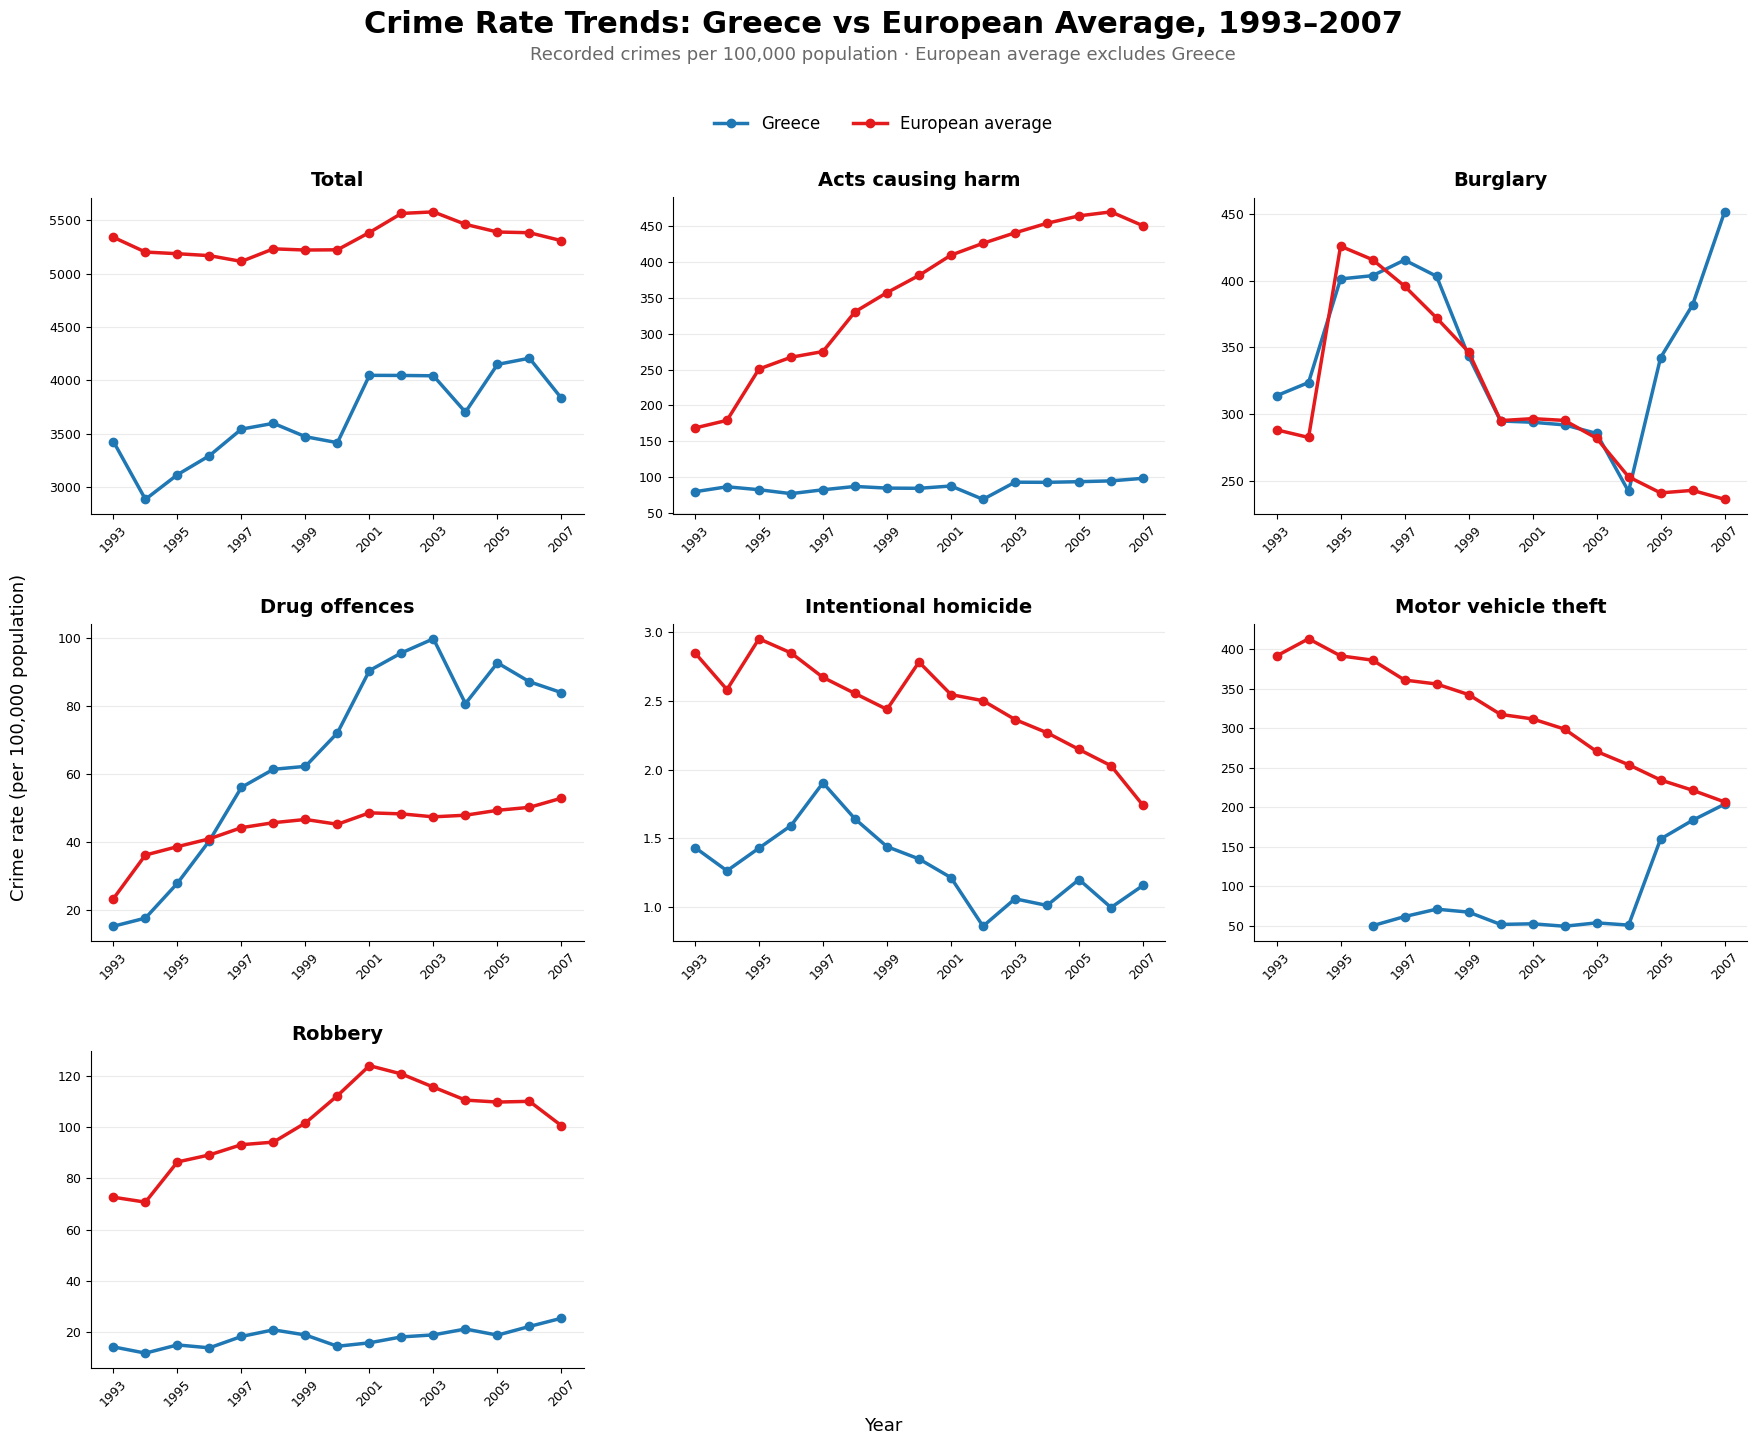

In [57]:
# Prepare data

plot_df = (
    analysis_df[
        analysis_df["Year"].between(1993, 2007)
    ]
    .dropna(subset=["Crime_Count", "Population"])
    .copy()
)

plot_df["Year"] = plot_df["Year"].astype(int)


# Greece trend by crime type and year

greece_trend = (
    plot_df[
        plot_df["Country"] == "Greece"
    ]
    .groupby(["Crime_Type", "Year"], as_index=False)
    .agg({
        "Crime_Count": "sum",
        "Population": "sum"
    })
)

greece_trend["Crime_per_100k"] = (
    greece_trend["Crime_Count"] / greece_trend["Population"] * 100000
)

greece_trend["Region"] = "Greece"


# European population-weighted average
# Greece excluded from the European benchmark

europe_trend = (
    plot_df[
        plot_df["Country"] != "Greece"
    ]
    .groupby(["Crime_Type", "Year"], as_index=False)
    .agg({
        "Crime_Count": "sum",
        "Population": "sum"
    })
)

europe_trend["Crime_per_100k"] = (
    europe_trend["Crime_Count"] / europe_trend["Population"] * 100000
)

europe_trend["Region"] = "European average"


# Combine Greece + Europe

trend_df = pd.concat(
    [greece_trend, europe_trend],
    ignore_index=True
)


# Crime type order — Total first

crime_types = sorted(trend_df["Crime_Type"].unique())

if "Total" in crime_types:
    crime_types = ["Total"] + [c for c in crime_types if c != "Total"]


# Create subplot grid

n_plots = len(crime_types)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows),
    sharex=True
)

axes = np.array(axes).flatten()


# Plot each crime type

for i, crime_type in enumerate(crime_types):

    ax = axes[i]

    temp = trend_df[
        trend_df["Crime_Type"] == crime_type
    ].copy()

    greece = temp[
        temp["Region"] == "Greece"
    ].sort_values("Year")

    europe = temp[
        temp["Region"] == "European average"
    ].sort_values("Year")

    ax.plot(
        greece["Year"],
        greece["Crime_per_100k"],
        marker="o",
        linewidth=2.5,
        color="#1f77b4",
        label="Greece"
    )

    ax.plot(
        europe["Year"],
        europe["Crime_per_100k"],
        marker="o",
        linewidth=2.5,
        color="#e41a1c",
        label="European average"
    )

    ax.set_title(
        crime_type,
        fontsize=14,
        fontweight="bold",
        pad=8
    )

    # Remove repeated axis labels from individual subplots
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Keep year ticks visible
    ax.set_xticks(range(1993, 2008, 2))
    ax.tick_params(
        axis="x",
        rotation=45,
        labelbottom=True
    )

    ax.tick_params(
        axis="both",
        labelsize=9
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Remove empty subplots


for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])



# Main title, subtitle and legend


fig.suptitle(
    "Crime Rate Trends: Greece vs European Average, 1993–2007",
    fontsize=22,
    fontweight="bold",
    y=0.985
)

fig.text(
    0.5,
    0.952,
    "Recorded crimes per 100,000 population · European average excludes Greece",
    ha="center",
    fontsize=13,
    color="dimgray"
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.925),
    ncol=2,
    frameon=False,
    fontsize=12
)



# Common axis labels for the whole figure


fig.supxlabel(
    "Year",
    fontsize=13,
    y=0.035
)

fig.supylabel(
    "Crime rate (per 100,000 population)",
    fontsize=13,
    x=0.015
)



# Layout adjustment


fig.subplots_adjust(
    top=0.86,
    bottom=0.08,
    left=0.06,
    right=0.98,
    hspace=0.35,
    wspace=0.18
)

plt.show()

### Evolution of Total Crime Rate Across European Countries

This trellis visualization illustrates the evolution of the total recorded crime rate for each European country between 1993-2007. By displaying all countries on a common y-axis scale, the plot enables direct comparisons of crime levels and temporal trends, making it easier to identify countries with consistently high or low crime rates as well as increasing or decreasing patterns over time.

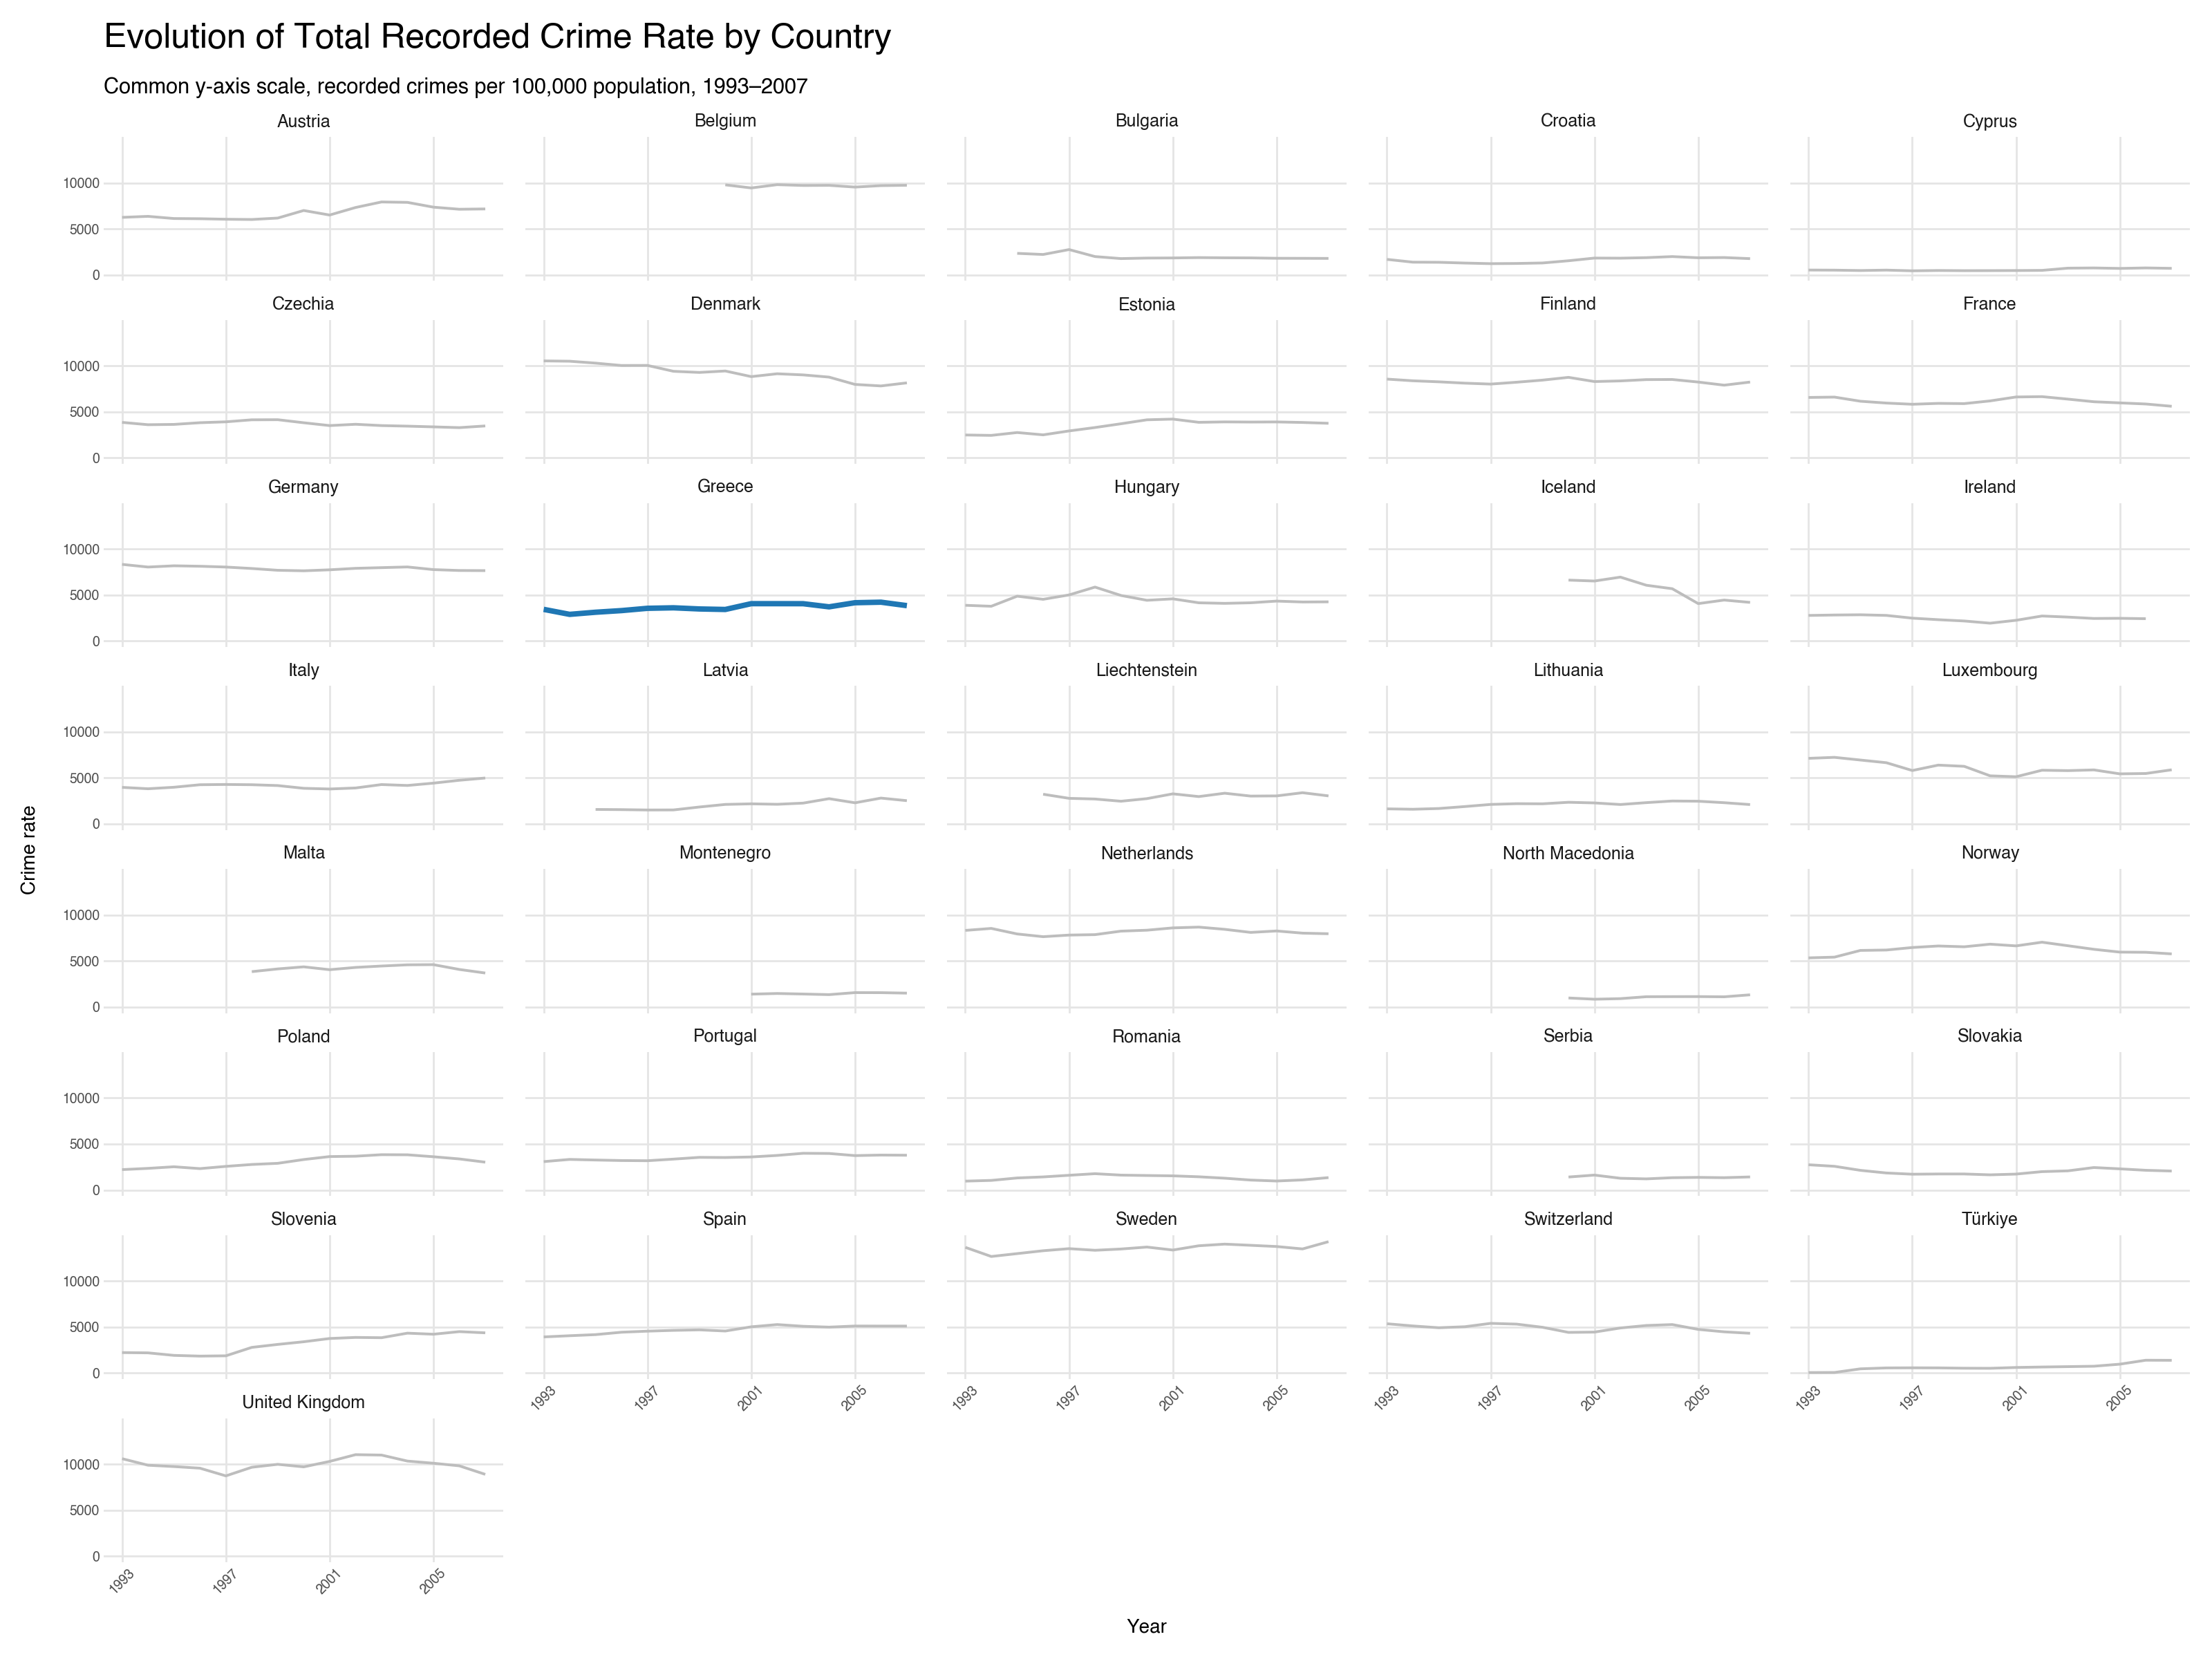

In [71]:
plot2_df = (
    analysis_df[
        analysis_df["Crime_Type"] == "Total"
    ]
    .copy()
)

plot2 = (
    ggplot(
        plot2_df,
        aes(
            x="Year",
            y="Crime_per_100k",
            group="Country"
        )
    )

   

    + geom_line(
    data=plot2_df[plot2_df["Country"] != "Greece"],
    color="#BDBDBD",
    size=0.8
    )
    + geom_line(
    data=plot2_df[plot2_df["Country"] == "Greece"],
    color="#1f77b4", 
    size=1.6
    )


    + facet_wrap(
        "~Country",
        ncol=5
    )

    + scale_x_continuous(
        breaks=[1993, 1997, 2001, 2005]
    )

    + labs(
        title="Evolution of Total Recorded Crime Rate by Country",
        subtitle="Common y-axis scale, recorded crimes per 100,000 population, 1993–2007",
        x="Year",
        y="Crime rate"
    )

    + theme_minimal()

    + theme(
        figure_size=(16, 12),
        plot_title=element_text(size=18, weight="bold"),
        plot_subtitle=element_text(size=11),
        strip_text=element_text(size=9, weight="bold"),
        
        axis_title=element_text(size=10),
        axis_text_x=element_text(rotation=45, size=7),
        axis_text_y=element_text(size=7),
        panel_grid_minor=element_blank()
    )
)

plot2

### Average Crime Rate by Type in Greece

This bar chart compares the average recorded crime rate of different offence categories in Greece between 1993 and 2007. It helps identify which crime types contributed most to the overall crime pattern in the country.

Burglary had by far the highest average crime rate in Greece during the period. Motor vehicle theft, acts causing harm, and drug offences followed at lower levels, while robbery and intentional homicide remained relatively low.

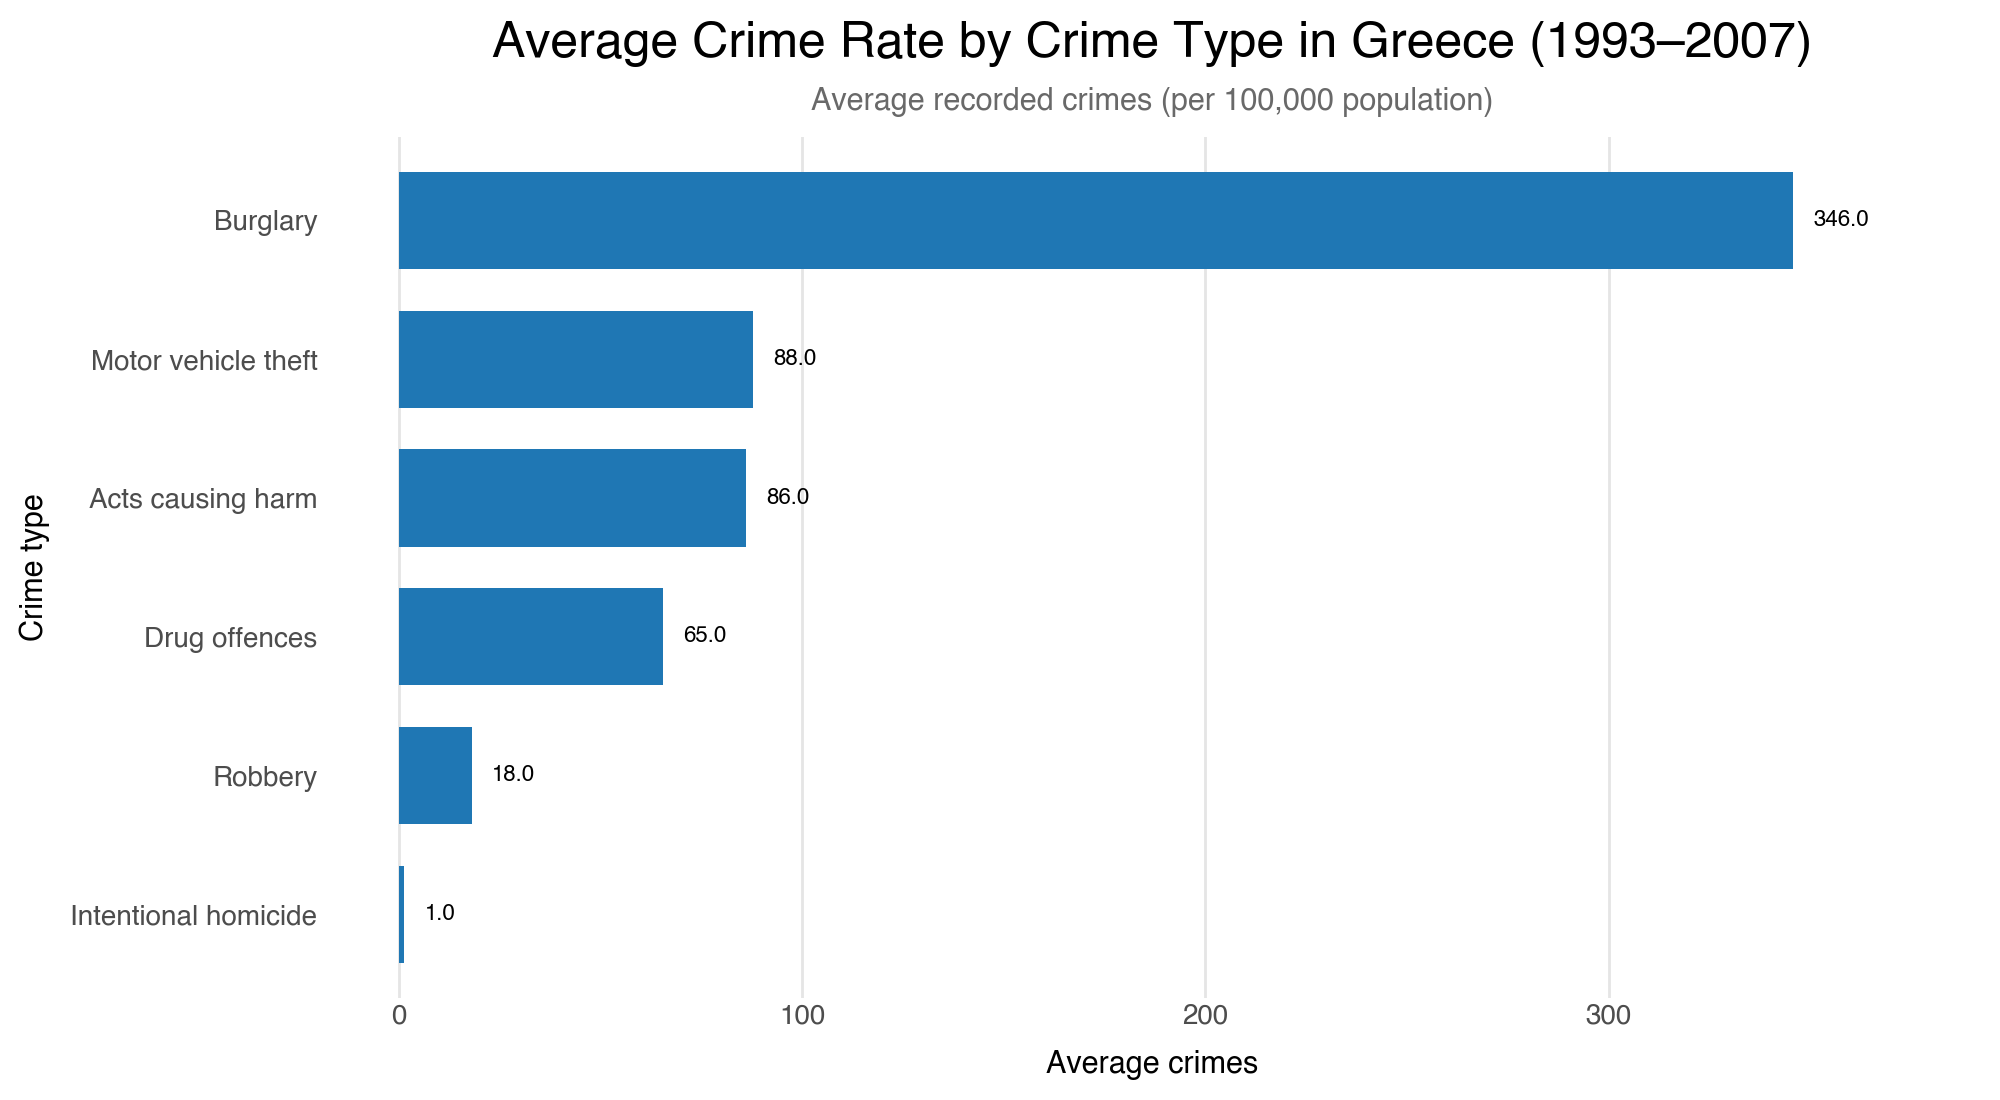

In [59]:
# Keep only Greece and exclude Total
greece_plot = (
    analysis_df[
        (analysis_df["Country"] == "Greece") &
        (analysis_df["Crime_Type"] != "Total")
    ]
    .groupby("Crime_Type", as_index=False)
    .agg(
        Avg_Rate=("Crime_per_100k", "mean")
    )
    .sort_values(
        "Avg_Rate",
        ascending=True
    )
)

# Create plot
plot3 = (
    ggplot(
        greece_plot,
        aes(
            x="reorder(Crime_Type, Avg_Rate)",
            y="Avg_Rate"
        )
    )

    # Bars
    + geom_col(
        fill="#1f77b4",
        width=0.70
    )

    # Value labels
    + geom_text(
        aes(label="round(Avg_Rate)"),
        ha="left",
        nudge_y=5,
        size=8
    )

    # Horizontal bars
    + coord_flip()

    # Extra space for labels
    + expand_limits(
        y=greece_plot["Avg_Rate"].max() * 1.08
    )

    # Labels
    + labs(
        title="Average Crime Rate by Crime Type in Greece (1993–2007)",
        subtitle="Average recorded crimes (per 100,000 population)",
        x="Crime type",
        y="Average crimes"
    )

    # Theme
    + theme_minimal()

    + theme(
        figure_size=(10, 5.5),

        plot_title=element_text(
            size=18,
            weight="bold",
            ha="center"
        ),

        plot_subtitle=element_text(
            size=11,
            color="dimgray",
            ha="center"
        ),

        axis_title=element_text(
            size=11
        ),

        axis_text=element_text(
            size=10
        ),

        panel_grid_minor=element_blank(),
        panel_grid_major_y=element_blank()
    )
)

plot3

### Average Total Crime Rate Across Europe

This map shows the average total crime rate across European countries from 1993 to 2007. It highlights the geographical differences in recorded crime levels across Europe.

Greece appears below many Northern and Western European countries, suggesting that its average crime rate was relatively moderate during the period.

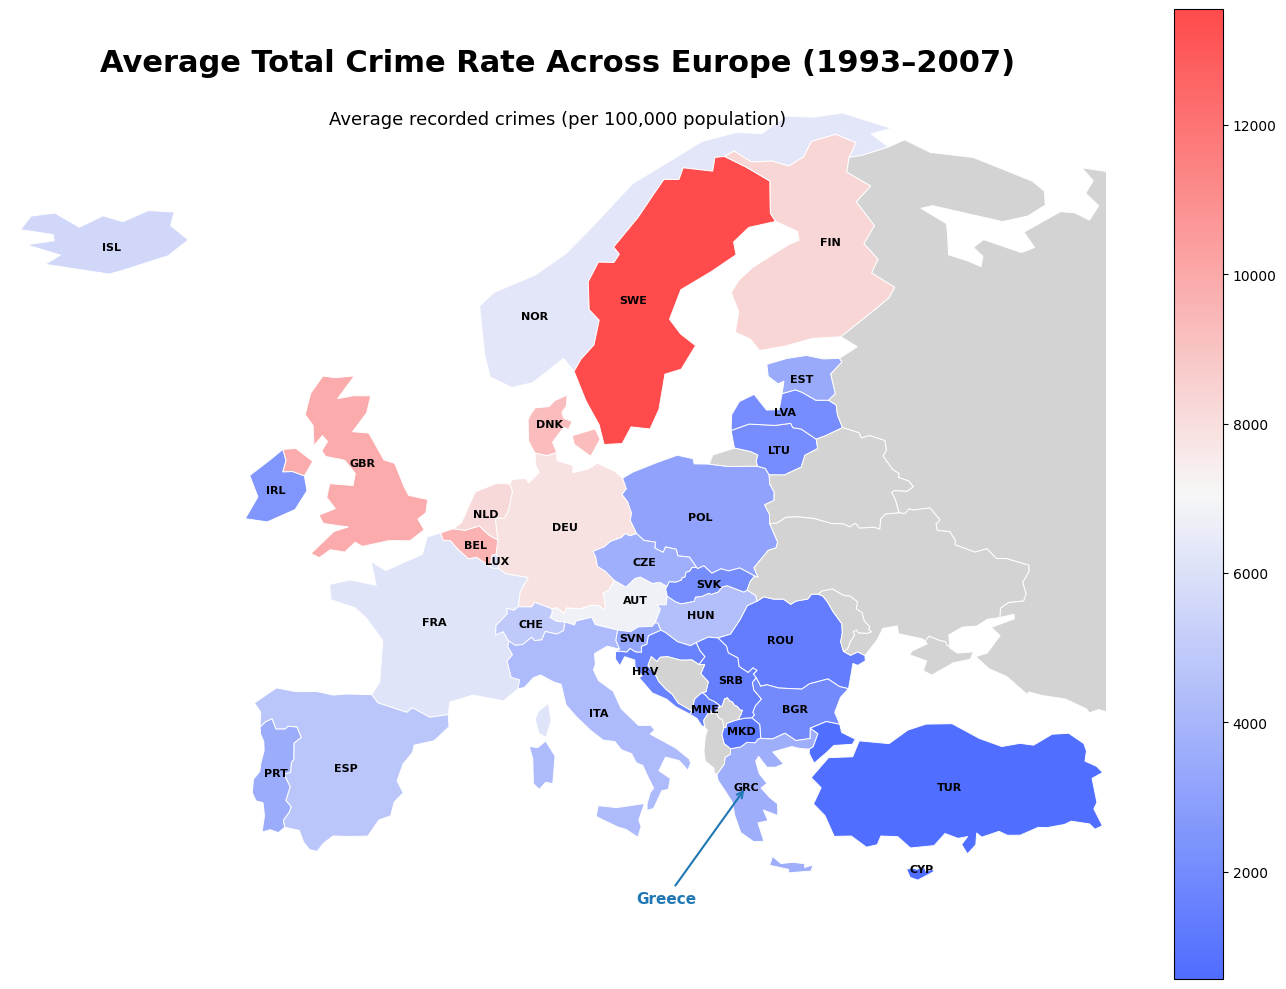

In [60]:
# Prepare data

map_source = analysis_df[
    analysis_df["Crime_Type"] == "Total"
].copy()

country_year = (
    map_source
    .groupby(["Country", "Year"], as_index=False)
    .agg({
        "Crime_Count": "sum",
        "Population": "sum"
    })
)

country_year["Crime_per_100k"] = (
    country_year["Crime_Count"] / country_year["Population"] * 100000
)

map_df = (
    country_year
    .groupby("Country", as_index=False)["Crime_per_100k"]
    .mean()
)


# Load Natural Earth countries

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)


# Keep Europe + Cyprus + Turkey

extra_countries = ["Cyprus", "Turkey"]

europe = world[
    (world["CONTINENT"] == "Europe") |
    (world["NAME"].isin(extra_countries))
].copy()


# Match map names with dataset names

name_map = {
    "Turkey": "Türkiye",
    "Bosnia and Herz.": "Bosnia and Herzegovina"
}

europe["Country_match"] = europe["NAME"].replace(name_map)


# Merge

europe_map = europe.merge(
    map_df,
    left_on="Country_match",
    right_on="Country",
    how="left"
)


# Custom blue-white-red palette

blue_white_red = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["#4F6DFF", "#F7F7F7", "#FF4B4B"]
)


# Plot

fig, ax = plt.subplots(figsize=(14, 10))

europe_map.plot(
    column="Crime_per_100k",
    cmap=blue_white_red,
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)


# Country labels

label_positions = {
    "Norway": (8.5, 61.5),
    "Iceland": (-18.5, 64.8),
    "Ireland": (-8.0, 53.2),
    "United Kingdom": (-2.5, 54.5),
    "Portugal": (-8.0, 39.7),
    "Greece": (22.0, 39.0),
    "Luxembourg": (6.1, 49.8),
    "Cyprus": (33.2, 35.1),
    "Türkiye": (35.0, 39.0)
}

for _, row in europe_map.iterrows():

    if pd.notnull(row["Crime_per_100k"]):

        country_name = row["Country_match"]

        if country_name in label_positions:
            x, y = label_positions[country_name]
        else:
            point = row.geometry.representative_point()
            x, y = point.x, point.y

        ax.text(
            x,
            y,
            row["ADM0_A3"],
            fontsize=8,
            fontweight="bold",
            ha="center",
            va="center",
            color="black"
        )


# Greece annotation  

ax.annotate(
    "Greece",
    xy=(22.0, 39.0),
    xytext=(15.0, 33.5),
    fontsize=11,
    fontweight="bold",
    color="#1f77b4",
    arrowprops=dict(
        arrowstyle="->",
        color="#1f77b4",
        linewidth=1.5
    )
)


# Title and subtitle

ax.set_title(
    "Average Total Crime Rate Across Europe (1993–2007)",
    fontsize=22,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    0.965,
    "Average recorded crimes (per 100,000 population)",
    transform=ax.transAxes,
    ha="center",
    fontsize=13
)

ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

ax.axis("off")

plt.tight_layout()
plt.show()

### Country-Level Average Total Crime Rates

This horizontal bar chart ranks European countries by their average total recorded crime rate over the period 1993–2007. Greece is highlighted to show its relative position, while the vertical reference line represents the European mean. This visualization provides a clear country-level comparison and helps assess whether Greece appears above or below the broader European pattern.


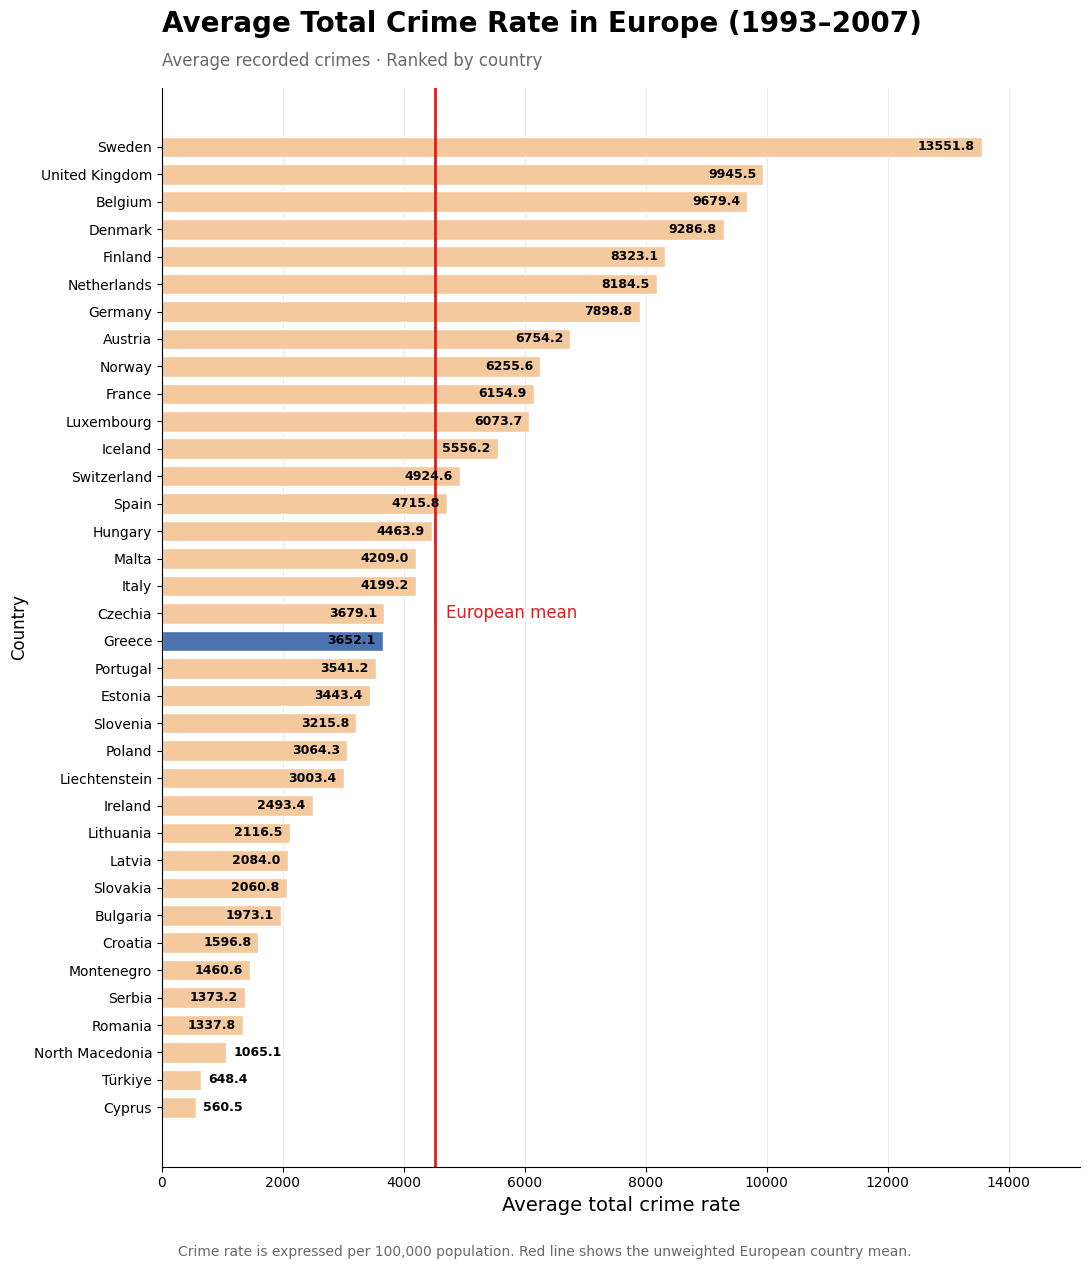

In [61]:
# Compute average total crime rate by country
# Period: 1993–2007

country_avg = (
    analysis_df[
        (analysis_df["Crime_Type"] == "Total") &
        (analysis_df["Year"].between(1993, 2007))
    ]
    .dropna(subset=["Crime_per_100k"])
    .groupby("Country", as_index=False)["Crime_per_100k"]
    .mean()
)


# Sort countries by average crime rate

country_avg = country_avg.sort_values(
    "Crime_per_100k",
    ascending=True
).reset_index(drop=True)


# European mean
# Unweighted mean across countries

europe_mean = country_avg["Crime_per_100k"].mean()


# Colors: highlight Greece

colors = np.where(
    country_avg["Country"] == "Greece",
    "#4C72B0",      # Greece
    "#F3C99D"       # Other countries
)


# Plot

fig, ax = plt.subplots(figsize=(11, 13))

bars = ax.barh(
    country_avg["Country"],
    country_avg["Crime_per_100k"],
    color=colors,
    edgecolor="white",
    height=0.75
)


# European mean line

ax.axvline(
    europe_mean,
    color="#E41A1C",
    linewidth=2
)

ax.text(
    europe_mean + 180,
    len(country_avg) * 0.50,
    "European mean",
    color="#E41A1C",
    fontsize=12,
    va="center"
)


# Value labels
# For large bars: inside
# For small bars: outside

for bar, value in zip(bars, country_avg["Crime_per_100k"]):

    y = bar.get_y() + bar.get_height() / 2

    if value >= 1200:
        ax.text(
            value - 120,
            y,
            f"{value:.1f}",
            va="center",
            ha="right",
            fontsize=9,
            fontweight="bold",
            color="black"
        )
    else:
        ax.text(
            value + 120,
            y,
            f"{value:.1f}",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold",
            color="black"
        )


# Titles and labels

ax.set_title(
    "Average Total Crime Rate in Europe (1993–2007)",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=40
)

# Subtitle
ax.text(
    0,
    1.02,
    "Average recorded crimes · Ranked by country",
    transform=ax.transAxes,
    fontsize=12,
    color="dimgray",
    ha="left"
)

ax.set_xlabel(
    "Average total crime rate",
    fontsize=14
)

ax.set_ylabel(
    "Country",
    fontsize=12
)


# Style

ax.grid(
    axis="x",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Leave enough space for labels
ax.set_xlim(
    0,
    country_avg["Crime_per_100k"].max() * 1.12
)

ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=10)


# Caption

fig.text(
    0.5,
    0.03,
    "Crime rate is expressed per 100,000 population. Red line shows the unweighted European country mean.",
    fontsize=10,
    color="dimgray",
    ha="center"
)


plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

### Greece Within Europe's Crime Distribution

This plot shows where Greece stands compared with the distribution of total recorded crime rates across European countries. The grey boxplots represent the spread of European countries each year, while the blue line tracks Greece.

Greece stays within the main European range during the whole period and is not an extreme outlier. In the 1990s, its crime rate is generally below the middle of the European distribution. After 2001, Greece moves closer to the European median, showing a moderate increase in recorded total crime rate.

Overall, the plot suggests that Greece experienced some increase over time, but its crime level remained relatively moderate compared with many other European countries.

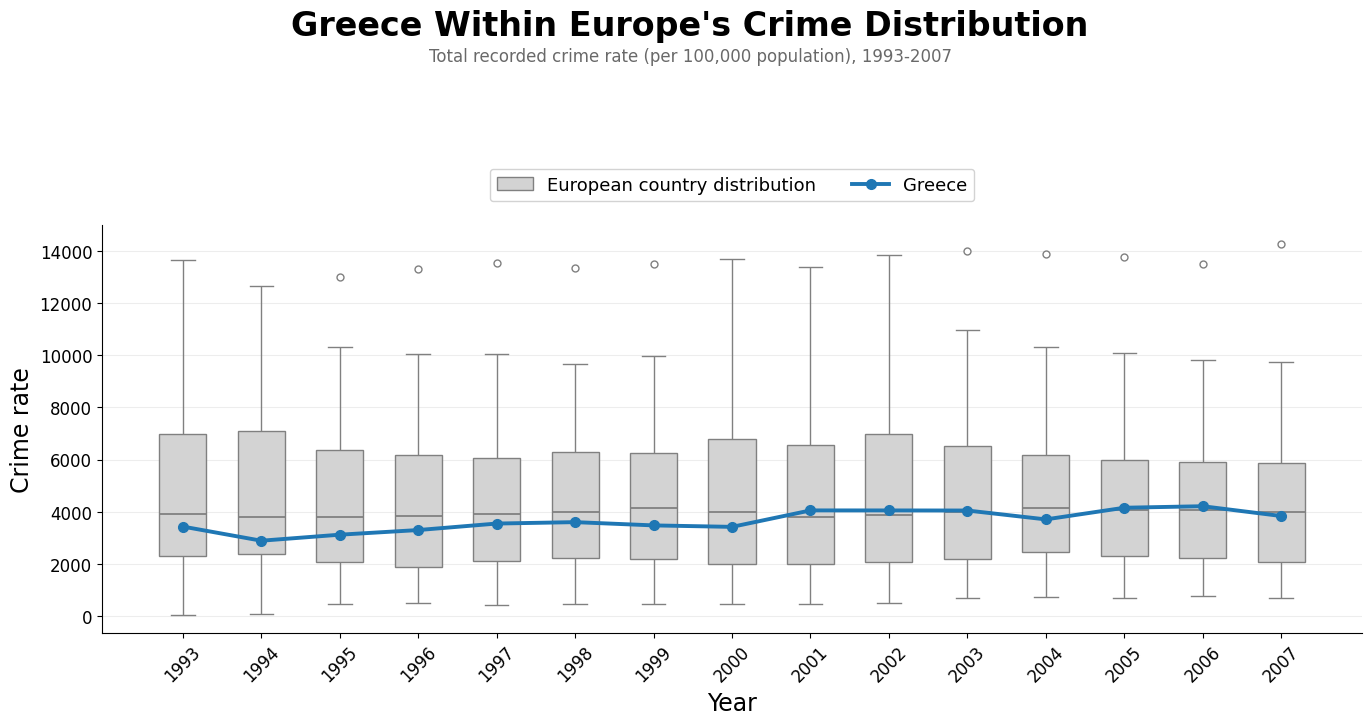

In [62]:
# Keep Total crime only

plot_df = (
    analysis_df[
        (analysis_df["Crime_Type"] == "Total") &
        (analysis_df["Year"].between(1993, 2007))
    ]
    .dropna(subset=["Crime_per_100k"])
    .copy()
)

plot_df["Year"] = plot_df["Year"].astype(int)

# Split Europe and Greece
# Europe distribution excludes Greece

europe_df = (
    plot_df[
        plot_df["Country"] != "Greece"
    ]
    .copy()
)

greece_df = (
    plot_df[
        plot_df["Country"] == "Greece"
    ]
    .copy()
    .sort_values("Year")
)

# Create clean year labels

years = sorted(plot_df["Year"].unique())

europe_df["Year_str"] = europe_df["Year"].astype(str)
greece_df["Year_str"] = greece_df["Year"].astype(str)

year_order = [str(y) for y in years]
year_to_x = {year: i for i, year in enumerate(year_order)}

greece_df["x_pos"] = greece_df["Year_str"].map(year_to_x)

# Plot

fig, ax = plt.subplots(figsize=(14, 8))

# Boxplots: European country distribution per year
sns.boxplot(
    data=europe_df,
    x="Year_str",
    y="Crime_per_100k",
    order=year_order,
    color="lightgray",
    width=0.6,
    showfliers=True,
    ax=ax,
    boxprops=dict(edgecolor="gray", linewidth=1),
    whiskerprops=dict(color="gray", linewidth=1),
    capprops=dict(color="gray", linewidth=1),
    medianprops=dict(color="gray", linewidth=1.3),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="gray",
        markersize=5,
        linestyle="none"
    )
)

# Greece line
ax.plot(
    greece_df["x_pos"],
    greece_df["Crime_per_100k"],
    color="#1f77b4",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Greece",
    zorder=4
)

# Title
fig.suptitle(
    "Greece Within Europe's Crime Distribution",
    fontsize=24,
    fontweight="bold",
    x=0.5,
    ha="center",
    y=0.96
)

# Subtitle  
fig.text(
    0.5,
    0.895,
    "Total recorded crime rate (per 100,000 population), 1993-2007",
    ha="center",
    fontsize=12,
    color="dimgray"
)

# Axis labels

ax.set_xlabel("Year", fontsize=17)
ax.set_ylabel("Crime rate", fontsize=17)

ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.tick_params(axis="y", labelsize=12)

# Custom legend

legend_elements = [
    Patch(
        facecolor="lightgray",
        edgecolor="gray",
        label="European country distribution"
    ),
    Line2D(
        [0],
        [0],
        color="#1f77b4",
        marker="o",
        linewidth=2.8,
        markersize=7,
        label="Greece"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.16),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=1,
    fontsize=13
)

# Style

ax.grid(axis="y", alpha=0.22)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.subplots_adjust(
    top=0.69,      
    bottom=0.18,
    left=0.08,
    right=0.98
)

plt.show()

### Crime Types in Greece

This heatmap shows how crime rates in Greece changed across offence categories from 1993 to 2007. Darker colors indicate higher crime rates, while gray cells represent missing data.

The plot shows that **burglary** had the highest crime rates throughout the period. It also suggests increases in categories such as **drug offences** and **motor vehicle theft**, while **intentional homicide** remained consistently low.

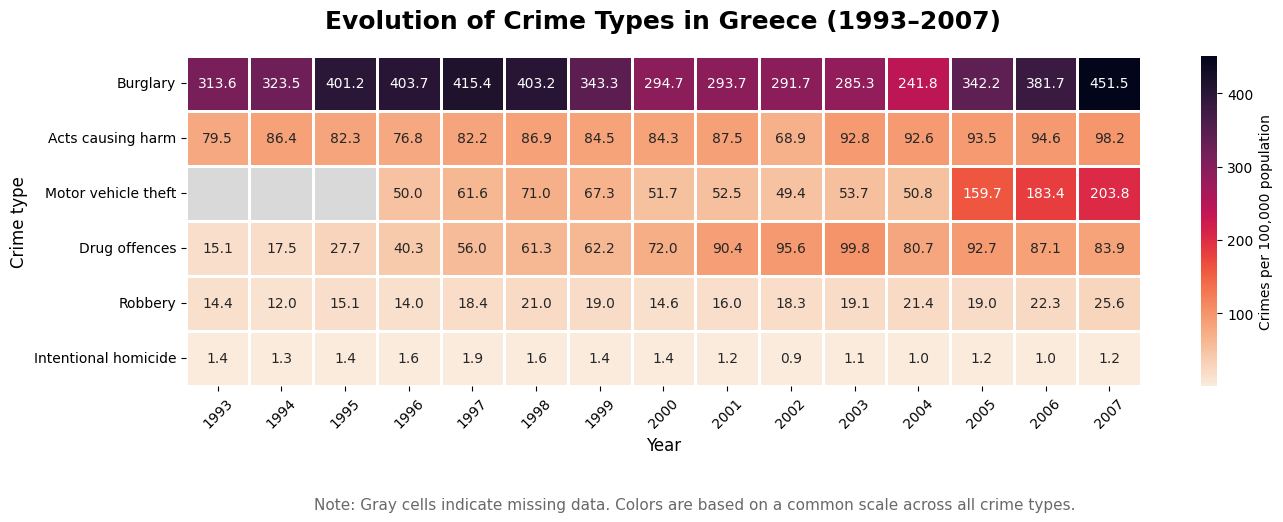

In [63]:
# Heatmap of Crime Types in Greece (1993–2007)
# Prepare data

heat_df = (
    analysis_df[
        (analysis_df["Country"] == "Greece") &
        (analysis_df["Crime_Type"] != "Total")
    ]
    .copy()
)

# Create matrix:
# rows = crime types
# columns = years
heat_matrix = (
    heat_df
    .pivot_table(
        index="Crime_Type",
        columns="Year",
        values="Crime_per_100k",
        aggfunc="mean"
    )
)

# Order rows 
order = [
    "Burglary",
    "Acts causing harm",
    "Motor vehicle theft",
    "Drug offences",
    "Robbery",
    "Intentional homicide"
]

order = [x for x in order if x in heat_matrix.index]

heat_matrix = heat_matrix.loc[order]

# Plot


fig, ax = plt.subplots(figsize=(14, 5))

# Create colormap and set missing values to gray
cmap = sns.color_palette("rocket_r", as_cmap=True)
cmap.set_bad("#d9d9d9")

sns.heatmap(
    heat_matrix,
    cmap=cmap,
    annot=True,
    fmt=".1f",
    linewidths=1,
    linecolor="white",
    cbar_kws={
        "label": "Crimes per 100,000 population"
    },
    ax=ax
)

ax.set_title(
    "Evolution of Crime Types in Greece (1993–2007)",
    fontsize=18,
    weight="bold",
    pad=20
)

ax.set_xlabel(
    "Year",
    fontsize=12
)

ax.set_ylabel(
    "Crime type",
    fontsize=12
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Note below the plot
fig.text(
    0.5,
    -0.03,
    "Note: Gray cells indicate missing data. Colors are based on a common scale across all crime types.",
    ha="center",
    fontsize=11,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### Crime Profile Clusters in Europe

This plot groups European countries based on their total crime profile between 1993 and 2007. The clustering uses the average crime rate, median crime rate, volatility, percentage change, and overall trend.

The axes are PCA-based dimensions used only to visualize similarities between countries. Countries that appear close to each other have more similar crime patterns.

Greece belongs to the **medium crime profile** cluster. This suggests that Greece does not follow the high-crime profile of countries such as Sweden, the United Kingdom, Denmark, and Germany, but is closer to countries with moderate recorded crime patterns.


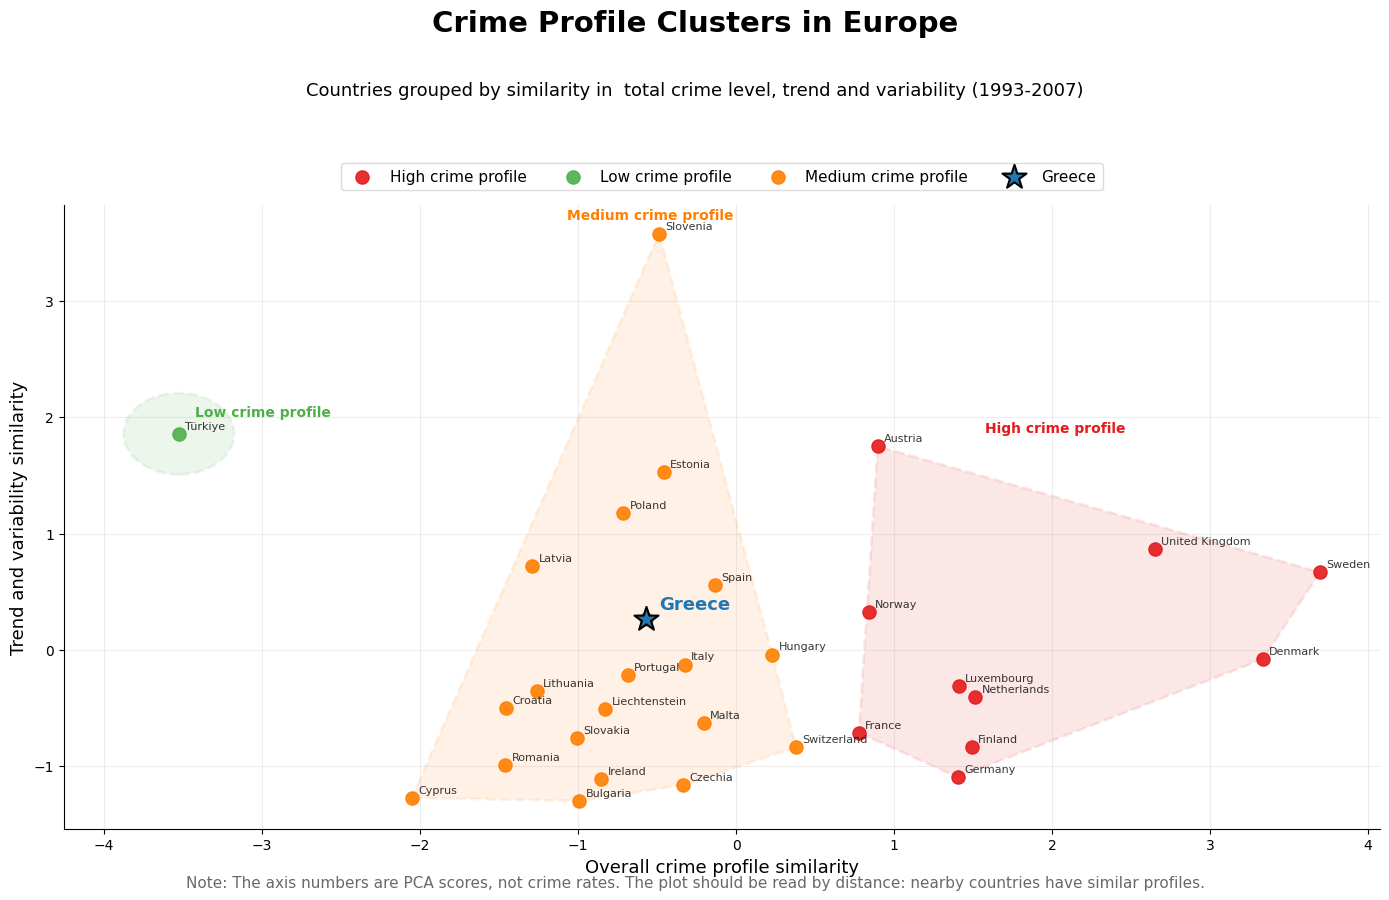

In [64]:
# Plot - Clustering European countries by total crime profile
# with convex hull polygons around clusters
#  Prepare data

cluster_df = (
    analysis_df[
        (analysis_df["Crime_Type"] == "Total") &
        (analysis_df["Year"].between(1993, 2007))
    ]
    .dropna(subset=["Crime_per_100k"])
    .copy()
)

cluster_df["Year"] = cluster_df["Year"].astype(int)

# Keep countries with enough yearly observations
valid_countries = (
    cluster_df
    .groupby("Country")["Year"]
    .nunique()
)

valid_countries = valid_countries[
    valid_countries >= 10
].index

cluster_df = cluster_df[
    cluster_df["Country"].isin(valid_countries)
].copy()


#  Feature engineering

feature_rows = []

for country, group in cluster_df.groupby("Country"):

    group = group.sort_values("Year")

    years = group["Year"].to_numpy()
    rates = group["Crime_per_100k"].to_numpy()

    avg_rate = np.mean(rates)
    median_rate = np.median(rates)
    volatility = np.std(rates)

    first_rate = rates[0]
    last_rate = rates[-1]

    pct_change = ((last_rate - first_rate) / first_rate) * 100

    trend_slope = np.polyfit(years, rates, 1)[0]

    feature_rows.append({
        "Country": country,
        "Average_rate": avg_rate,
        "Median_rate": median_rate,
        "Volatility": volatility,
        "Pct_change": pct_change,
        "Trend_slope": trend_slope
    })

features_df = pd.DataFrame(feature_rows)


#  Scale features

feature_cols = [
    "Average_rate",
    "Median_rate",
    "Volatility",
    "Pct_change",
    "Trend_slope"
]

X = features_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#  KMeans clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

features_df["Cluster"] = kmeans.fit_predict(X_scaled)

# Rename clusters based on average crime rate
cluster_order = (
    features_df
    .groupby("Cluster")["Average_rate"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

cluster_labels = {
    cluster_order[0]: "Low crime profile",
    cluster_order[1]: "Medium crime profile",
    cluster_order[2]: "High crime profile"
}

features_df["Cluster_label"] = features_df["Cluster"].map(cluster_labels)


#  PCA for 2D visualization

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

features_df["PC1"] = pca_coords[:, 0]
features_df["PC2"] = pca_coords[:, 1]


# Convex Hull helper

def convex_hull(points):
    """
    Monotone chain convex hull.
    Input: list/array of (x, y) points
    Output: hull points in order
    """
    points = sorted(set(map(tuple, points)))

    if len(points) <= 1:
        return np.array(points)

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for p in points:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    upper = []
    for p in reversed(points):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    hull = lower[:-1] + upper[:-1]
    return np.array(hull)


def draw_cluster_shape(ax, x, y, color, label, alpha=0.10, linewidth=2):
    """
    Draw cluster polygon/hull.
    - 1 point: small circle
    - 2 points: circle around both
    - 3+ points: convex hull polygon
    """
    points = np.column_stack([x, y])

    
    if len(points) == 1:
        circle = Circle(
            xy=(points[0, 0], points[0, 1]),
            radius=0.35,
            facecolor=color,
            edgecolor=color,
            alpha=alpha,
            linewidth=linewidth,
            linestyle="--"
        )
        ax.add_patch(circle)

        ax.text(
            points[0, 0] + 0.10,
            points[0, 1] + 0.15,
            label,
            fontsize=10,
            fontweight="bold",
            color=color
        )
        return

    
    if len(points) == 2:
        center = points.mean(axis=0)
        radius = np.max(np.linalg.norm(points - center, axis=1)) + 0.25

        circle = Circle(
            xy=(center[0], center[1]),
            radius=radius,
            facecolor=color,
            edgecolor=color,
            alpha=alpha,
            linewidth=linewidth,
            linestyle="--"
        )
        ax.add_patch(circle)

        ax.text(
            center[0],
            center[1] + radius + 0.10,
            label,
            fontsize=10,
            fontweight="bold",
            color=color,
            ha="center"
        )
        return

    
    hull = convex_hull(points)

    poly = Polygon(
        hull,
        closed=True,
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=linewidth,
        linestyle="--"
    )
    ax.add_patch(poly)

    # place label near top-center of hull
    label_x = hull[:, 0].mean()
    label_y = hull[:, 1].max() + 0.12

    ax.text(
        label_x,
        label_y,
        label,
        fontsize=10,
        fontweight="bold",
        color=color,
        ha="center"
    )


# Plot

fig, ax = plt.subplots(figsize=(14, 9))

colors = {
    "Low crime profile": "#4daf4a",
    "Medium crime profile": "#ff7f00",
    "High crime profile": "#e41a1c"
}

cluster_plot_order = [
    "High crime profile",
    "Low crime profile",
    "Medium crime profile"
]

# Draw cluster polygons first
for label in cluster_plot_order:

    temp = features_df[
        features_df["Cluster_label"] == label
    ]

    if len(temp) > 0:
        draw_cluster_shape(
            ax=ax,
            x=temp["PC1"].values,
            y=temp["PC2"].values,
            color=colors[label],
            label=label,
            alpha=0.10,
            linewidth=2
        )

# Draw points
for label in cluster_plot_order:

    temp = features_df[
        features_df["Cluster_label"] == label
    ]

    if len(temp) > 0:
        ax.scatter(
            temp["PC1"],
            temp["PC2"],
            s=90,
            alpha=0.90,
            color=colors[label],
            label=label,
            zorder=3
        )

# Highlight Greece
greece_point = features_df[
    features_df["Country"] == "Greece"
]

if not greece_point.empty:
    ax.scatter(
        greece_point["PC1"],
        greece_point["PC2"],
        s=330,
        color="#1f77b4",
        edgecolor="black",
        linewidth=1.5,
        marker="*",
        label="Greece",
        zorder=5
    )

    ax.text(
        greece_point["PC1"].iloc[0] + 0.08,
        greece_point["PC2"].iloc[0] + 0.08,
        "Greece",
        fontsize=13,
        fontweight="bold",
        color="#1f77b4",
        zorder=6
    )

# Country labels
for _, row in features_df.iterrows():
    if row["Country"] != "Greece":
        ax.text(
            row["PC1"] + 0.04,
            row["PC2"] + 0.04,
            row["Country"],
            fontsize=8,
            alpha=0.78,
            zorder=4
        )

# Titles and labels
fig.suptitle(
    "Crime Profile Clusters in Europe",
    fontsize=21,
    fontweight="bold",
    x=0.5,
    ha="center",
    y=0.98
)

fig.text(
    0.5,
    0.885,
    "Countries grouped by similarity in  total crime level, trend and variability (1993-2007)",
    fontsize=13,
    ha="center"
)

ax.set_xlabel(
    "Overall crime profile similarity",
    fontsize=13
)

ax.set_ylabel(
    "Trend and variability similarity",
    fontsize=13
)

fig.text(
    0.5,
    0.005,
    "Note: The axis numbers are PCA scores, not crime rates. The plot should be read by distance: nearby countries have similar profiles.",
    ha="center",
    fontsize=11,
    color="dimgray"
)
# Style
ax.grid(alpha=0.22)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.show()



### Crime Level and Change Across Europe

This plot compares each country’s average total crime rate with its absolute change between 1993 and 2007. The vertical red line shows the European average crime level, while the horizontal dashed line separates countries with increasing and decreasing total crime rates.

Greece appears below the European average crime level, but above the zero-change line. This means that Greece was not among the high-crime countries in Europe, but its total recorded crime rate increased during the period.

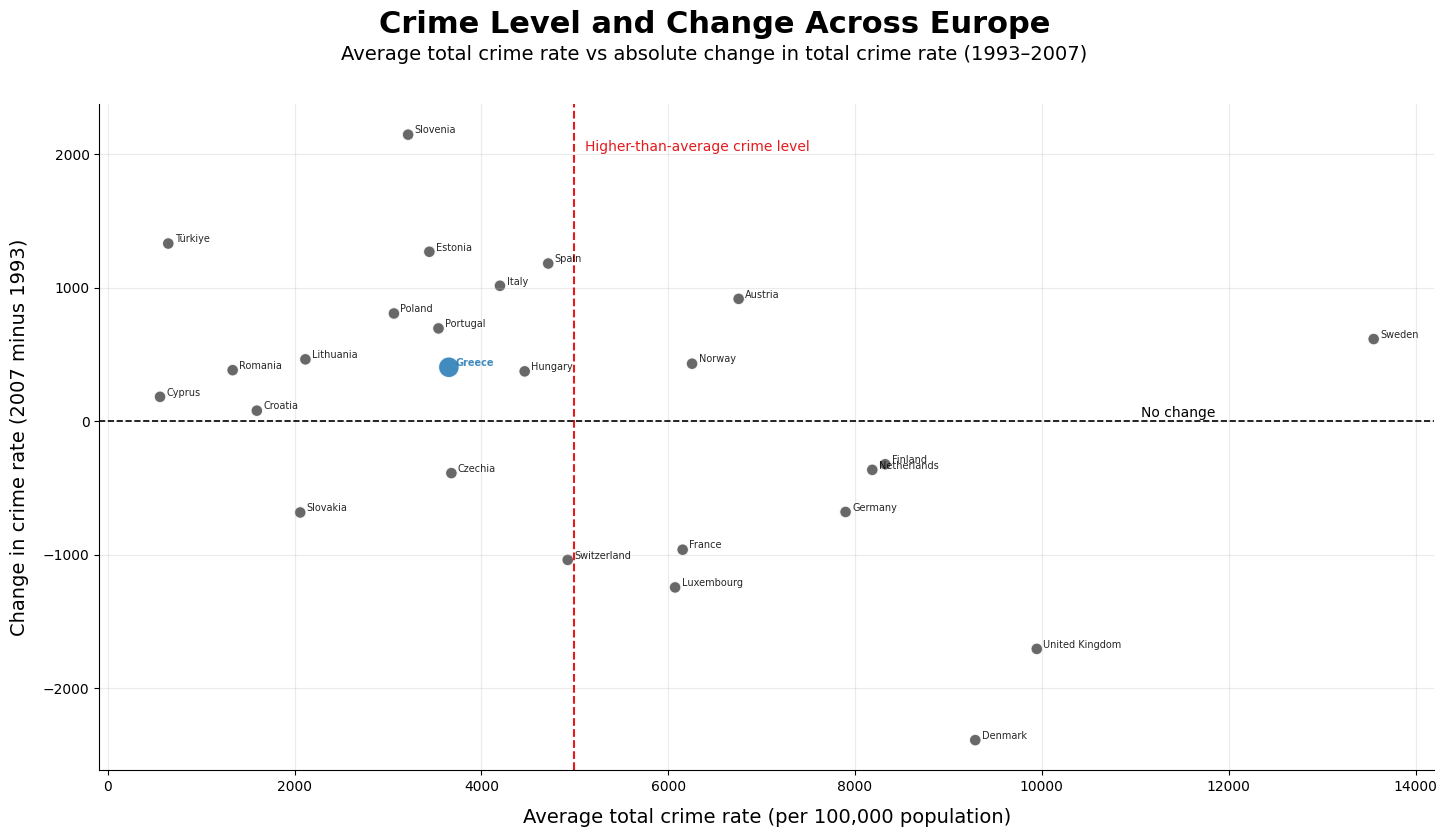

In [65]:
# Plot - Crime level and change across Europe

# Keep Total crime only
plot_df = (
    analysis_df[
        (analysis_df["Crime_Type"] == "Total") &
        (analysis_df["Year"].between(1993, 2007))
    ]
    .dropna(subset=["Crime_per_100k"])
    .copy()
)

plot_df["Year"] = plot_df["Year"].astype(int)


# Compute country-level features

rows = []

for country, group in plot_df.groupby("Country"):
    
    group = group.sort_values("Year")
    
    # Keep only countries that have both 1993 and 2007
    if 1993 not in group["Year"].values or 2007 not in group["Year"].values:
        continue
    
    start_rate = group.loc[group["Year"] == 1993, "Crime_per_100k"].iloc[0]
    end_rate = group.loc[group["Year"] == 2007, "Crime_per_100k"].iloc[0]
    avg_rate = group["Crime_per_100k"].mean()
    abs_change = end_rate - start_rate
    
    rows.append({
        "Country": country,
        "Average_rate": avg_rate,
        "Absolute_change": abs_change
    })

scatter_df = pd.DataFrame(rows)


# Reference line: European average level

europe_avg_rate = scatter_df["Average_rate"].mean()


# Highlight Greece

scatter_df["Color"] = np.where(
    scatter_df["Country"] == "Greece",
    "#1f77b4",
    "#4D4D4D"
)

scatter_df["Size"] = np.where(
    scatter_df["Country"] == "Greece",
    220,
    70
)


# Create figure

fig, ax = plt.subplots(figsize=(15, 9))

# Leave space above the plot for title and subtitle
fig.subplots_adjust(
    top=0.86,
    left=0.09,
    right=0.98,
    bottom=0.12
)


# Scatter plot

ax.scatter(
    scatter_df["Average_rate"],
    scatter_df["Absolute_change"],
    s=scatter_df["Size"],
    c=scatter_df["Color"],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)


# Quadrant reference lines

ax.axvline(
    europe_avg_rate,
    color="#E41A1C",
    linestyle="--",
    linewidth=1.5
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2
)


# Country labels

for _, row in scatter_df.iterrows():
    ax.text(
        row["Average_rate"] + 70,
        row["Absolute_change"] + 10,
        row["Country"],
        fontsize=7,
        fontweight="bold" if row["Country"] == "Greece" else "normal",
        color="#1f77b4" if row["Country"] == "Greece" else "black",
        alpha=0.85
    )


# Title and subtitle outside the plot area


fig.suptitle(
    "Crime Level and Change Across Europe",
    fontsize=22,
    fontweight="bold",
    x=0.5,
    y=0.965,
    ha="center"
)

fig.text(
    0.5,
    0.91,
    "Average total crime rate vs absolute change in total crime rate (1993–2007)",
    fontsize=14,
    ha="center"
)



# Axis labels


ax.set_xlabel(
    "Average total crime rate (per 100,000 population)",
    fontsize=14,
    labelpad=10
)

ax.set_ylabel(
    "Change in crime rate (2007 minus 1993)",
    fontsize=14,
    labelpad=10
)


# Quadrant labels

x_left, x_right = ax.get_xlim()
y_bottom, y_top = ax.get_ylim()

ax.text(
    europe_avg_rate + 120,
    y_top - 0.07 * (y_top - y_bottom),
    "Higher-than-average crime level",
    color="#E41A1C",
    fontsize=10
)

ax.text(
    x_right - 0.22 * (x_right - x_left),
    35,
    "No change",
    color="black",
    fontsize=10
)



# Style

ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=10
)

plt.show()

### Greece’s Crime Rank in Europe

This plot shows Greece’s yearly rank among European countries based on the total recorded crime rate per 100,000 population. A lower rank means a relatively higher crime rate compared with other countries.

Greece remains in the lower half of the European ranking throughout the period, indicating that it was generally below the high-crime countries of Europe. Although its exact position changes slightly over time, Greece does not move close to the top of the ranking.

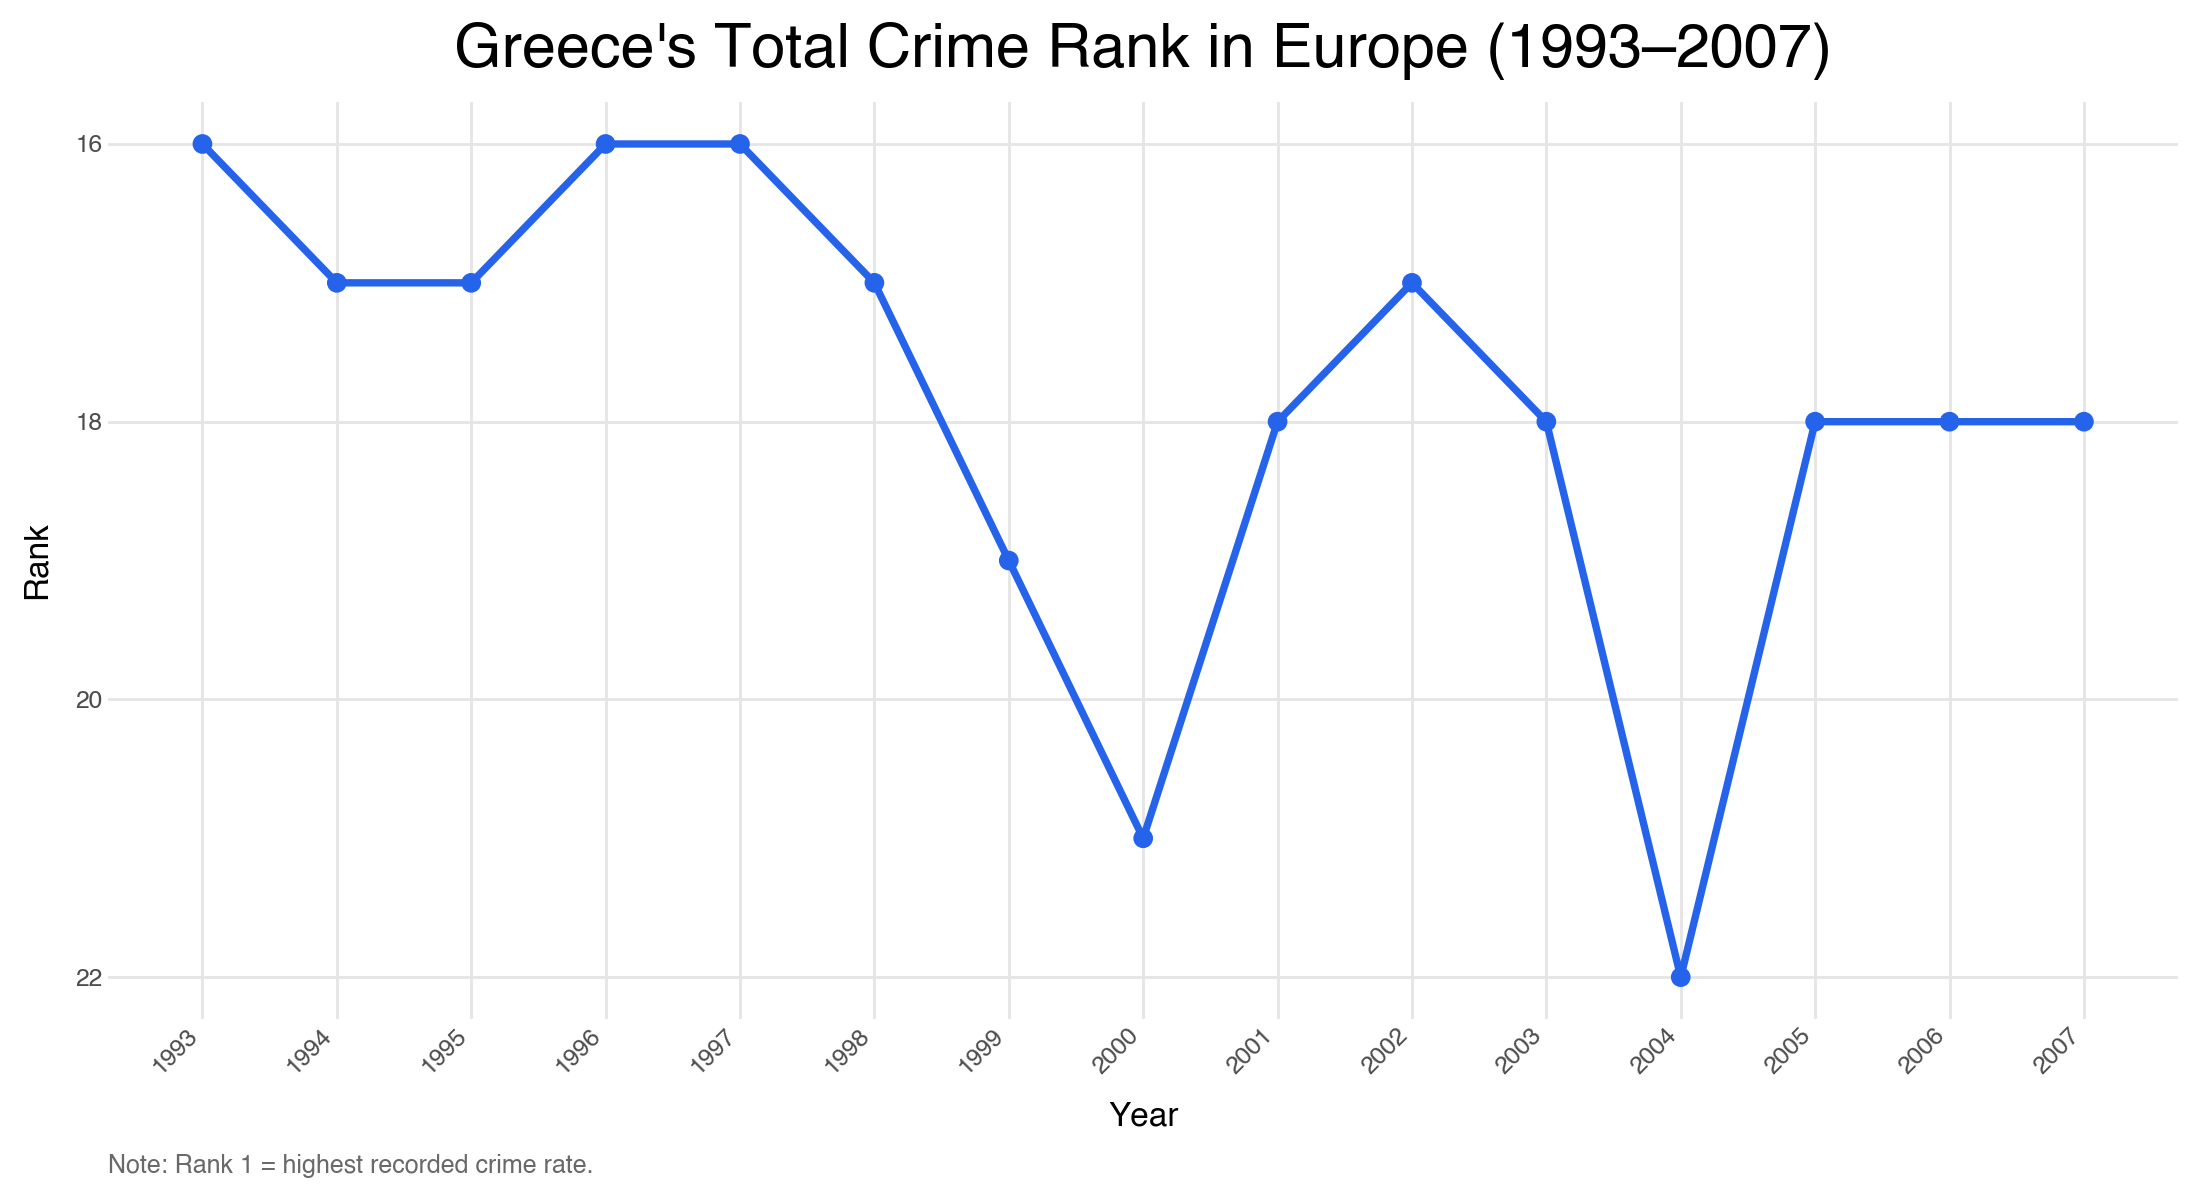

In [66]:
# Keep Total crime only

rank_df = (
    analysis_df[
        (analysis_df["Crime_Type"] == "Total") &
        (analysis_df["Year"].between(1993, 2007))
    ]
    .dropna(subset=["Crime_per_100k"])
    .copy()
)


# Compute yearly ranking
# Highest crime rate = rank 1

rank_df["Rank"] = (
    rank_df
    .groupby("Year")["Crime_per_100k"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Total number of countries per year 
n_countries = int(rank_df.groupby("Year")["Country"].nunique().median())

# Keep Greece only

greece_rank = (
    rank_df[
        rank_df["Country"] == "Greece"
    ]
    .copy()
)


# Plot

plot_rank = (
    ggplot(
        greece_rank,
        aes(
            x="Year",
            y="Rank"
        )
    )

    + geom_line(
        color="#2563EB",
        size=1.5
    )

    + geom_point(
        color="#2563EB",
        size=3
    )

    + scale_x_continuous(
        breaks=sorted(greece_rank["Year"].unique())
    )

    + scale_y_reverse()

    + labs(
        title="Greece's Total Crime Rank in Europe (1993–2007)",
        x="Year",
        y="Rank",
        caption=f"Note: Rank 1 = highest recorded crime rate."  
    )

    + theme_minimal()

    + theme(
        figure_size=(11, 6),

        plot_title=element_text(
            size=22,
            weight="bold",
            ha="center"
        ),

        plot_subtitle=element_text(
            size=11,
            ha="center",
            color="dimgray"
        ),

        plot_caption=element_text(
            size=9,
            ha="left",
            color="dimgray"
        ),

        axis_title=element_text(size=12),
        axis_text_x=element_text(rotation=45, ha="right"),

        panel_grid_minor=element_blank()
    )
)

plot_rank

### Percentage Change in Crime Types in Greece

This bar chart shows how each crime category changed in Greece between 1993 and 2007. Positive values indicate an increase in the crime rate, while negative values indicate a decrease. Drug offences show the strongest increase, suggesting that this category changed substantially during the period. Robbery and burglary also increased, while intentional homicide slightly decreased.

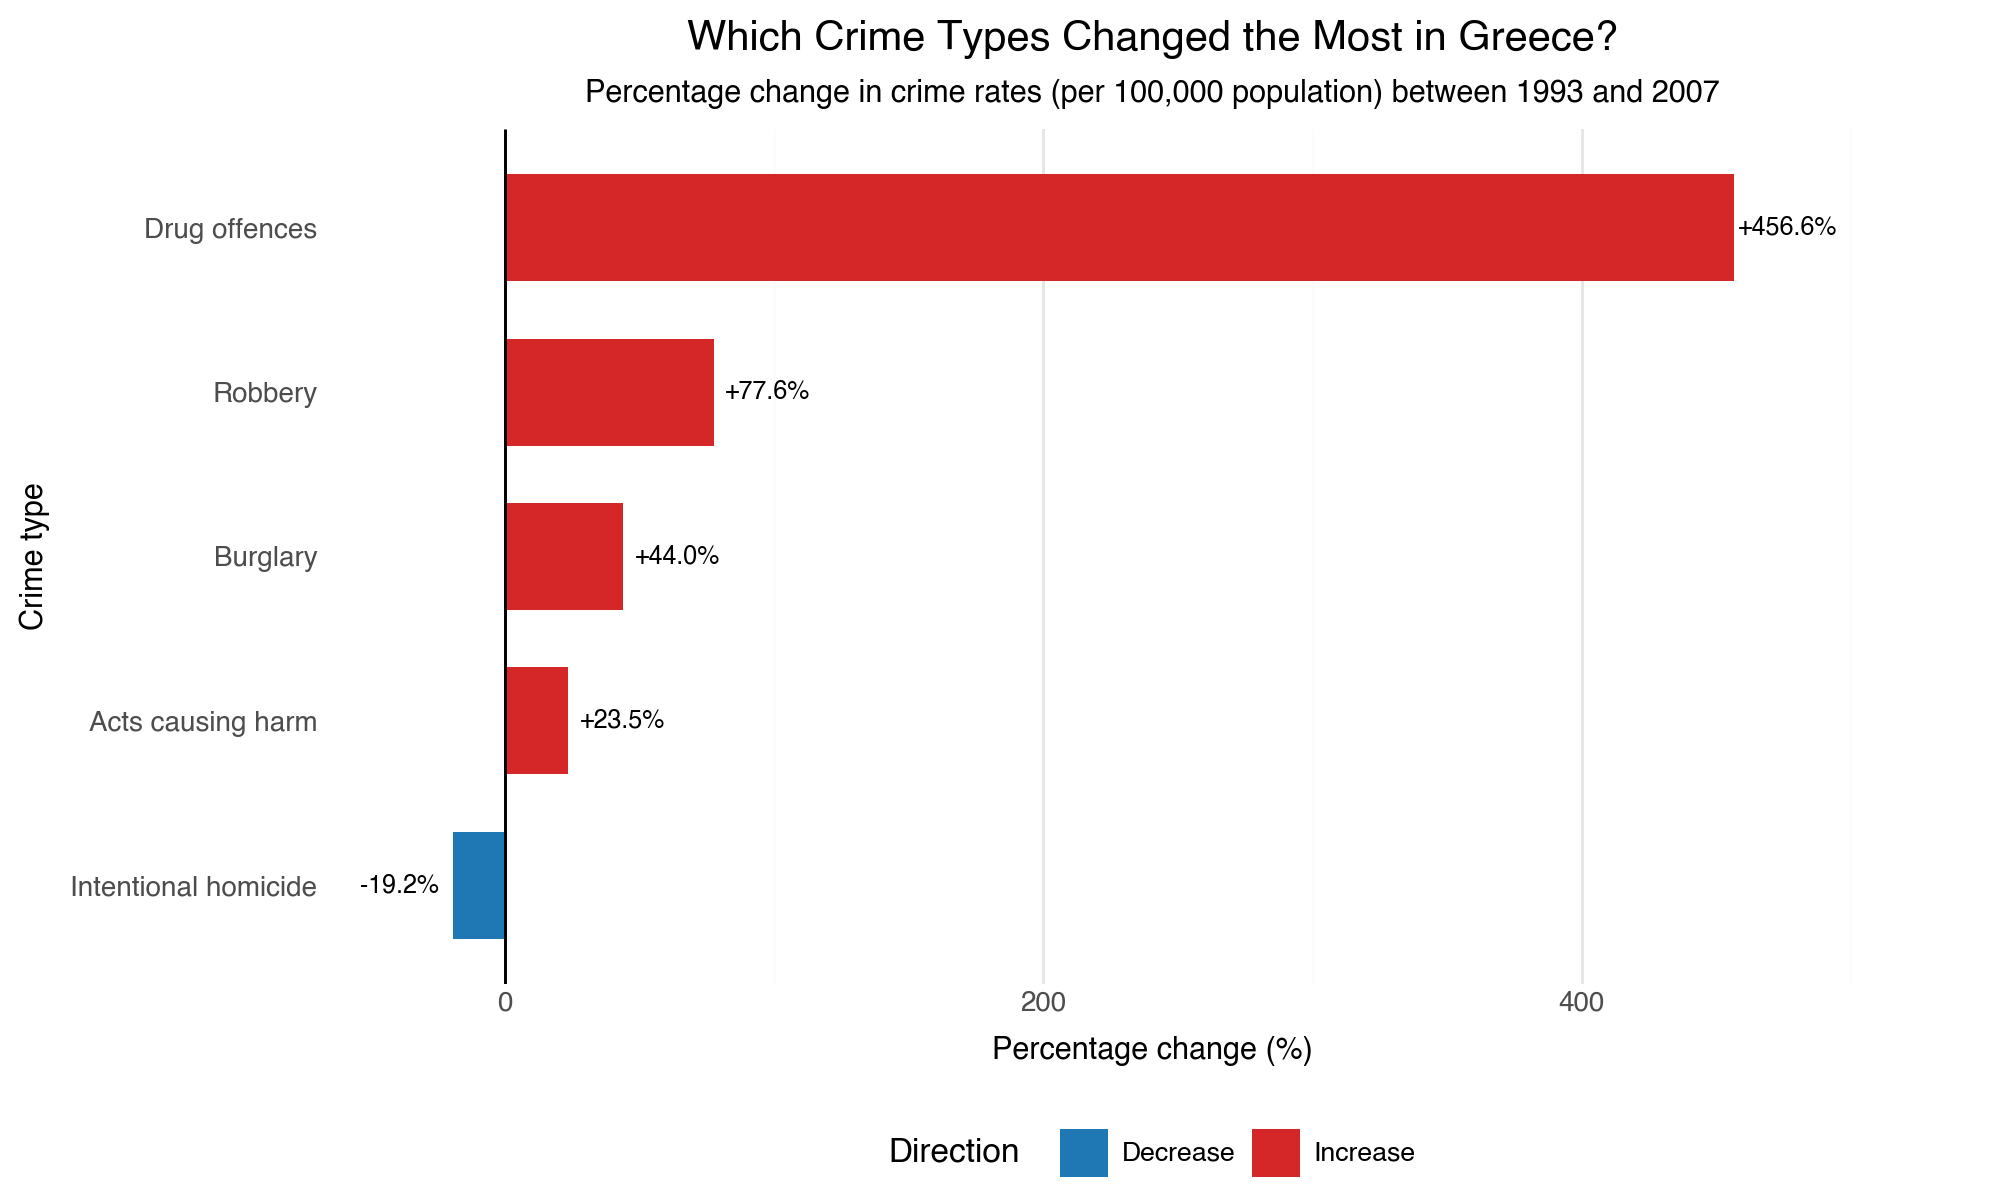

In [67]:
# Percentage change in Greece crime rates
# 1993 vs 2007
# Keep Greece only and exclude Total
greece_change = (
    analysis_df[
        (analysis_df["Country"] == "Greece") &
        (analysis_df["Crime_Type"] != "Total") &
        (analysis_df["Year"].isin([1993, 2007]))
    ]
    .copy()
)

# Reshape to wide format
greece_change_wide = (
    greece_change
    .pivot_table(
        index="Crime_Type",
        columns="Year",
        values="Crime_per_100k"
    )
    .reset_index()
    .dropna()
)

# Rename columns
greece_change_wide.columns = ["Crime_Type", "Rate_1993", "Rate_2007"]

# Compute percentage change
greece_change_wide["Percent_Change"] = (
    (greece_change_wide["Rate_2007"] - greece_change_wide["Rate_1993"])
    / greece_change_wide["Rate_1993"] * 100
)

# Direction of change
greece_change_wide["Direction"] = np.where(
    greece_change_wide["Percent_Change"] >= 0,
    "Increase",
    "Decrease"
)

# Labels
greece_change_wide["Change_Label"] = (
    np.where(
        greece_change_wide["Percent_Change"] >= 0,
        "+",
        ""
    )
    + greece_change_wide["Percent_Change"].round(1).astype(str)
    + "%"
)

# Label position
greece_change_wide["Label_x"] = np.where(
    greece_change_wide["Percent_Change"] >= 0,
    greece_change_wide["Percent_Change"] + 20,
    greece_change_wide["Percent_Change"] - 20
)

# Plot
plot11 = (
    ggplot(
        greece_change_wide,
        aes(
            x="reorder(Crime_Type, Percent_Change)",
            y="Percent_Change",
            fill="Direction"
        )
    )

    + geom_col(width=0.65)

    # Zero reference line
    + geom_hline(
        yintercept=0,
        color="black",
        size=0.6
    )

    # Percentage labels
    + geom_text(
        aes(
            y="Label_x",
            label="Change_Label"
        ),
        size=9
    )

    + coord_flip()

    + scale_fill_manual(
        values={
            "Increase": "#d62728",
            "Decrease": "#1f77b4"
        }
    )

    + labs(
        title="Which Crime Types Changed the Most in Greece?",
        subtitle="Percentage change in crime rates (per 100,000 population) between 1993 and 2007",
        x="Crime type",
        y="Percentage change (%)",
        fill="Direction"
    )

    + theme_minimal(base_size=12)

    + theme(
        figure_size=(10, 6),
        plot_title=element_text(weight="bold", size=15, ha="center"),
        plot_subtitle=element_text(size=11, ha="center"),
        axis_title=element_text(size=11),
        axis_text=element_text(size=10),
        legend_position="bottom",
        panel_grid_major_y=element_blank()
    )

    + expand_limits(
        y=520
    )
)

plot11

### Export Cleaned Dataset for Tableau

After completing the preprocessing and cleaning steps, the final dataset is exported to an Excel file so it can be used in Tableau for the interactive visualizations.

The exported file contains the cleaned analysis dataset, including the standardized crime rates per 100,000 population. This makes the Tableau visualizations consistent with the static plots in this notebook and allows fair comparisons between countries with different population sizes.


In [69]:
analysis_df.to_excel(
    "crime_analysis_tableau.xlsx",
    index=False
)

print("Tableau dataset exported successfully.")

Tableau dataset exported successfully.
